# Consciousness Field Toy Model: Portable Notebook

This notebook is a standalone presentation of a small field-based model of conscious organization. It is structured to be readable on its own, without any external notes or companion files.

The notebook moves in a deliberate order:

1. define the state space and parameter regimes
2. define observables and failure signatures
3. define the update dynamics
4. instantiate canonical scenarios
5. run baseline evaluations
6. compare regime-sensitive sweeps

The intent is not to claim realism, but to make the model assumptions explicit, executable, and easy to inspect.

Outputs are written under `portable_artifacts/`.

## Environment setup

This short setup cell attempts to make plotting available in notebook environments that support package installation. The model itself does not depend on plotting; figures are optional and the analysis still runs if plotting is unavailable.

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\david\OneDrive\Desktop\Projects\models\cons\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "c:\Users\david\OneDrive\Desktop\Projects\models\cons\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "c:\Users\david\OneDrive\Desktop\Projects\models\cons\.venv\Lib\site-packages\pip\_internal\cli\req_command.py", line 96, in wrapper
    return func(self, options, args)
  File "c:\Users\david\OneDrive\Desktop\Projects\models\cons\.venv\Lib\site-packages\pip\_internal\commands\install.py", line 377, in run
    resolver = self.make_resolver(
        preparer=preparer,
    ...<8 lines>...
        py_version_info=options.python_version,
    )
  File "c:\Users\david\OneDrive\Desktop\Projects\models\cons\.venv\Lib\site-packages\pip\_internal\cli\req_co

## Core state and parameter regimes

This section defines the basic vocabulary of the model: tokens, orientation, subject-position, residue, and the field state that holds them together.

It also introduces a compact parameter discipline. Rather than scattering unexplained coefficients throughout the code, the notebook groups them into interpretable regime settings such as salience gain, articulation bandwidth, persistence, decay, closure pressure, correction sensitivity, affective amplification, and cross-mode coupling.

In [1]:
from dataclasses import dataclass, field
from pathlib import Path
from copy import deepcopy
from collections import defaultdict
from statistics import mean
from typing import Any, Callable, Dict, Iterable, List, Mapping, MutableMapping, Set
import csv
import json

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

MODES = {"perc", "aff", "mood", "cog", "imag", "body", "refl"}
FG_THRESHOLD = 0.35

def clamp(value: float, lower: float = 0.0, upper: float = 1.0) -> float:
    return max(lower, min(upper, value))

def _clamp01(value: float) -> float:
    return max(0.0, min(1.0, value))

@dataclass
class ParameterSet:
    salience_gain: float = 0.55
    articulation_bandwidth: float = 0.65
    persistence: float = 0.55
    decay: float = 0.45
    closure_weight: float = 0.4
    correction_sensitivity: float = 0.7
    affective_amplification: float = 0.55
    cross_mode_coupling: float = 0.7

    def normalized(self) -> "ParameterSet":
        return ParameterSet(
            salience_gain=_clamp01(self.salience_gain),
            articulation_bandwidth=_clamp01(self.articulation_bandwidth),
            persistence=_clamp01(self.persistence),
            decay=_clamp01(self.decay),
            closure_weight=_clamp01(self.closure_weight),
            correction_sensitivity=_clamp01(self.correction_sensitivity),
            affective_amplification=_clamp01(self.affective_amplification),
            cross_mode_coupling=_clamp01(self.cross_mode_coupling),
        )

    def derived_ratios(self) -> Dict[str, float]:
        articulation = max(0.05, self.articulation_bandwidth)
        decay = max(0.05, self.decay)
        correction = max(0.05, self.correction_sensitivity)
        return {
            "closure_to_correction": round(self.closure_weight / correction, 4),
            "salience_to_articulation": round((self.salience_gain + self.affective_amplification) / articulation, 4),
            "persistence_to_decay": round(self.persistence / decay, 4),
            "cross_mode_integration": round(self.cross_mode_coupling, 4),
        }

    def as_dict(self) -> Dict[str, float]:
        return {
            "salience_gain": self.salience_gain,
            "articulation_bandwidth": self.articulation_bandwidth,
            "persistence": self.persistence,
            "decay": self.decay,
            "closure_weight": self.closure_weight,
            "correction_sensitivity": self.correction_sensitivity,
            "affective_amplification": self.affective_amplification,
            "cross_mode_coupling": self.cross_mode_coupling,
        }

REGIMES = {
    "open_revisable": ParameterSet(0.55, 0.7, 0.55, 0.45, 0.35, 0.78, 0.5, 0.72),
    "pressure_heavy": ParameterSet(0.78, 0.28, 0.55, 0.45, 0.48, 0.35, 0.8, 0.58),
    "fixation_rumination": ParameterSet(0.68, 0.52, 0.82, 0.22, 0.82, 0.24, 0.7, 0.55),
    "fragmentation_dissociation": ParameterSet(0.5, 0.4, 0.26, 0.76, 0.24, 0.45, 0.55, 0.22),
    "closure_heavy": ParameterSet(0.62, 0.5, 0.62, 0.36, 0.84, 0.22, 0.6, 0.55),
}

def get_regime(name: str) -> ParameterSet:
    return REGIMES[name].normalized()

@dataclass
class MatterToken:
    token_id: str
    label: str
    modes: Set[str]
    salience: float
    articulation: float
    carriage: float
    uptake: float
    weighting: float
    fg_bg_position: float
    age: int = 0
    metadata: Dict[str, Any] = field(default_factory=dict)
    history: List[Dict[str, float]] = field(default_factory=list)

    def snapshot(self) -> Dict[str, Any]:
        return {
            "token_id": self.token_id,
            "label": self.label,
            "modes": sorted(self.modes),
            "salience": self.salience,
            "articulation": self.articulation,
            "carriage": self.carriage,
            "uptake": self.uptake,
            "weighting": self.weighting,
            "fg_bg_position": self.fg_bg_position,
            "age": self.age,
        }

    def record_history(self) -> None:
        self.history.append({
            "salience": self.salience,
            "articulation": self.articulation,
            "carriage": self.carriage,
            "uptake": self.uptake,
            "weighting": self.weighting,
            "fg_bg_position": self.fg_bg_position,
        })

@dataclass
class OrientationState:
    threat_readiness: float = 0.2
    task_focus: float = 0.4
    social_sensitivity: float = 0.3
    fatigue_pressure: float = 0.2
    anticipatory_pull: float = 0.3
    exploration_openness: float = 0.4
    withdrawal_tendency: float = 0.2

    def apply_delta(self, delta: Mapping[str, float]) -> None:
        for key, value in delta.items():
            if hasattr(self, key):
                setattr(self, key, clamp(getattr(self, key) + value))

@dataclass
class SubjectPosition:
    stability: float = 0.7
    self_world_boundary: float = 0.6
    agency: float = 0.65
    reflexive_access: float = 0.55

    def apply_delta(self, delta: Mapping[str, float]) -> None:
        for key, value in delta.items():
            if hasattr(self, key):
                setattr(self, key, clamp(getattr(self, key) + value))

@dataclass
class ResidueTrace:
    label: str
    modes: Set[str]
    unresolved_pressure: float
    reentry_bias: float = 0.0
    age: int = 0
    source_weighting: float = 0.0

    def step(self) -> None:
        self.age += 1
        self.unresolved_pressure = clamp(self.unresolved_pressure * 0.97)
        self.reentry_bias = clamp(self.reentry_bias * 0.98)

@dataclass
class FieldState:
    tokens: MutableMapping[str, MatterToken]
    orientation: OrientationState = field(default_factory=OrientationState)
    subject_position: SubjectPosition = field(default_factory=SubjectPosition)
    parameters: ParameterSet = field(default_factory=lambda: get_regime("open_revisable"))
    residue: List[ResidueTrace] = field(default_factory=list)
    relations: Dict[tuple[str, str], float] = field(default_factory=dict)
    step_index: int = 0
    events: List[str] = field(default_factory=list)

    def token_list(self) -> List[MatterToken]:
        return list(self.tokens.values())

    def add_event(self, event: str) -> None:
        self.events.append(event)

def make_token(label: str, modes: Iterable[str], salience: float, articulation: float, carriage: float, uptake: float, weighting: float, fg_bg_position: float, token_id: str | None = None, metadata: Mapping[str, Any] | None = None) -> MatterToken:
    return MatterToken(
        token_id=token_id or label.lower().replace(" ", "_"),
        label=label,
        modes=set(modes),
        salience=clamp(salience),
        articulation=clamp(articulation),
        carriage=clamp(carriage),
        uptake=clamp(uptake),
        weighting=clamp(weighting),
        fg_bg_position=clamp(fg_bg_position, -1.0, 1.0),
        metadata=dict(metadata or {}),
    )

## Observables and failure signatures

The next section defines the quantities used to interpret the field over time. Some summarize organization, such as coherence, integration, fragmentation, and residue pressure. Others flag characteristic breakdowns, such as weak carriage, failed uptake, premature closure, fixation, and dissociative disconnection.

These are operational choices for this toy model. They are not measurements of consciousness in general; they are bookkeeping rules that let different scenarios be compared in a reproducible way.

In [2]:
def residue_pressure(state: FieldState) -> float:
    active_component = sum((1.0 - token.articulation) * token.weighting for token in state.token_list() if token.carriage < 0.55 or token.fg_bg_position < 0.0)
    residue_component = sum(trace.unresolved_pressure for trace in state.residue)
    return round(active_component + residue_component, 4)

def coherence_score(state: FieldState) -> float:
    tokens = state.token_list()
    if len(tokens) < 2:
        return 1.0
    pair_scores = []
    for i, left in enumerate(tokens):
        for right in tokens[i + 1:]:
            relation = state.relations.get((left.label, right.label), state.relations.get((right.label, left.label), 0.0))
            mode_overlap = len(left.modes & right.modes) / max(1, len(left.modes | right.modes))
            profile_similarity = 1.0 - min(1.0, (abs(left.salience - right.salience) + abs(left.weighting - right.weighting) + abs(left.fg_bg_position - right.fg_bg_position) / 2.0) / 3.0)
            pair_scores.append(clamp(0.45 * ((relation + 1.0) / 2.0) + 0.25 * mode_overlap + 0.30 * profile_similarity))
    return round(mean(pair_scores), 4)

def integration_score(state: FieldState) -> float:
    tokens = state.token_list()
    if not tokens:
        return 0.0
    cross_mode = sum(max(0, len(token.modes) - 1) for token in tokens) / (len(tokens) * 3)
    uptake_carry = mean((token.uptake + token.carriage) / 2.0 for token in tokens)
    sigma = mean([state.subject_position.stability, state.subject_position.agency, state.subject_position.reflexive_access])
    return round(clamp(0.35 * cross_mode + 0.35 * uptake_carry + 0.30 * sigma), 4)

def fragmentation_score(state: FieldState) -> float:
    return round(clamp(1.0 - ((coherence_score(state) + integration_score(state)) / 2.0)), 4)

def field_diversity(state: FieldState) -> float:
    tokens = state.token_list()
    if not tokens:
        return 0.0
    grouped = defaultdict(int)
    for token in tokens:
        for mode in token.modes:
            grouped[mode] += 1
    active_modes = sum(1 for count in grouped.values() if count > 0)
    return round(active_modes / 7.0, 4)

def metric_snapshot(state: FieldState) -> Dict[str, float]:
    return {
        "coherence": coherence_score(state),
        "integration": integration_score(state),
        "fragmentation": fragmentation_score(state),
        "residue_pressure": residue_pressure(state),
        "field_diversity": field_diversity(state),
    }

def history_rows_by_step(history: Iterable[Mapping[str, object]]) -> Dict[int, List[Mapping[str, object]]]:
    grouped: Dict[int, List[Mapping[str, object]]] = defaultdict(list)
    for row in history:
        grouped[int(row["step"])].append(row)
    return dict(grouped)

def fixation_index(history: Iterable[Mapping[str, object]], token_label: str, window: int = 4) -> float:
    rows = [row for row in history if row.get("label") == token_label]
    if not rows:
        return 0.0
    recent = rows[-min(window, len(rows)): ]
    return round(sum(float(row["salience"]) * float(row["weighting"]) for row in recent) / max(1, len(recent)), 4)

def dominance_profile(history: Iterable[Mapping[str, object]], token_label: str, window: int = 4) -> Dict[str, float]:
    grouped = history_rows_by_step(history)
    if not grouped:
        return {"win_rate": 0.0, "avg_margin": 0.0, "avg_fg_bg_position": 0.0, "avg_field_diversity": 0.0}
    recent_steps = sorted(grouped)[-window:]
    wins = 0
    margins = []
    foreground_positions = []
    field_diversities = []
    for step in recent_steps:
        rows = grouped[step]
        ranked = sorted(rows, key=lambda row: float(row["salience"]) * float(row["weighting"]), reverse=True)
        top = ranked[0]
        top_product = float(top["salience"]) * float(top["weighting"])
        second_product = float(ranked[1]["salience"]) * float(ranked[1]["weighting"]) if len(ranked) > 1 else 0.0
        if str(top["label"]) == token_label:
            wins += 1
            margins.append(top_product - second_product)
            foreground_positions.append(float(top["fg_bg_position"]))
        field_diversities.append(float(top.get("field_diversity", 0.0)))
    return {
        "win_rate": round(wins / max(1, len(recent_steps)), 4),
        "avg_margin": round(sum(margins) / max(1, len(margins)), 4),
        "avg_fg_bg_position": round(sum(foreground_positions) / max(1, len(foreground_positions)), 4),
        "avg_field_diversity": round(sum(field_diversities) / max(1, len(field_diversities)), 4),
    }

def detect_weak_carriage(state: FieldState) -> List[str]:
    return [token.label for token in state.token_list() if token.carriage < 0.35 and token.salience > 0.2 and token.weighting > 0.25]

def detect_failed_uptake(state: FieldState) -> List[str]:
    return [token.label for token in state.token_list() if token.uptake < 0.3 and token.salience > 0.25 and token.weighting > 0.3]

def detect_premature_closure(state: FieldState) -> List[str]:
    pressure = residue_pressure(state)
    closure_ratio = state.parameters.derived_ratios()["closure_to_correction"]
    detected = []
    for token in state.token_list():
        if "refl" not in token.modes:
            continue
        unresolved_competitors = [other for other in state.token_list() if other.label != token.label and other.weighting > 0.3 and other.articulation < max(0.45, token.articulation - 0.25) and state.relations.get((token.label, other.label), state.relations.get((other.label, token.label), 0.0)) < 0.0]
        if closure_ratio >= 1.2 and token.articulation > 0.72 and pressure > 0.85 and token.weighting > 0.45 and state.subject_position.reflexive_access >= 0.35 and unresolved_competitors:
            detected.append(token.label)
    return detected

def detect_fragmentation(state: FieldState) -> bool:
    return fragmentation_score(state) > 0.59

def detect_dissociative_disconnection(state: FieldState) -> List[str]:
    disconnected = []
    integration = integration_score(state)
    for token in state.token_list():
        embodied = "body" in token.modes or "aff" in token.modes
        missing_uptake_bridge = "cog" not in token.modes and token.uptake < 0.3
        weak_subject_bridge = state.subject_position.stability < 0.62 and integration < 0.5
        if embodied and missing_uptake_bridge and weak_subject_bridge and token.weighting > 0.35 and token.carriage < 0.45:
            disconnected.append(token.label)
    return disconnected

def detect_fixation(history: Iterable[Mapping[str, object]], token_label: str, threshold: float = 0.42) -> bool:
    fixation = fixation_index(history, token_label)
    dominance = dominance_profile(history, token_label)
    return fixation >= threshold and dominance["win_rate"] >= 0.75 and dominance["avg_margin"] >= 0.12 and dominance["avg_fg_bg_position"] >= 0.15

def summarize_failures(state: FieldState, history: Iterable[Mapping[str, object]]) -> Dict[str, object]:
    labels = [token.label for token in state.token_list()]
    return {
        "weak_carriage": detect_weak_carriage(state),
        "failed_uptake": detect_failed_uptake(state),
        "premature_closure": detect_premature_closure(state),
        "fragmentation": detect_fragmentation(state),
        "dissociative_disconnection": detect_dissociative_disconnection(state),
        "fixation": [label for label in labels if detect_fixation(history, label)],
    }

## Explicit assumptions and non-claims

This notebook makes four code-level commitments explicit before the dynamics are introduced:

- Tokens are disclosures or contents-as-presented within the field, not objects in the world.
- Field organization is represented operationally through weighting, carriage, articulation, uptake, and foreground/background position.
- Failure labels are operational signatures inside this toy model, not diagnoses of consciousness in general.
- Scenarios are regime exemplars constructed for comparison, not empirical case studies.

These assumptions are meant to make the notebook self-interpreting. The code models a small vocabulary of organization and breakdown under stated assumptions; it does not claim to exhaust lived experience or provide a faithful simulation of consciousness as such.

## Dynamics engine

This section implements the update rules as named sub-updates so the inner step logic stays inspectable. Each step combines orientation drift, relation-based influence, explicit interventions, decay into residue, and possible recurrence from residue back into the active field.

The governing idea is that field organization is not determined by salience alone. Weighting, carriage, articulation, uptake, inter-token relations, and regime-level parameters jointly shape what stabilizes, what recedes, and what returns.

In [3]:
@dataclass
class StepResult:
    state: FieldState
    metrics: Dict[str, float]
    failures: Dict[str, object]

@dataclass
class TokenUpdateContext:
    relation_push: float
    salience_push: float
    articulation_push: float
    carriage_push: float
    uptake_push: float
    weighting_push: float
    fg_push: float
    dominant_label: str | None
    dominant_weight: float
    correction_drive: float
    closure_drive: float
    suppression: float

class FieldSimulator:
    def __init__(self, initial_state: FieldState):
        self.state = deepcopy(initial_state)
        self.history: List[Dict[str, object]] = []
        self.metric_history: List[Dict[str, float]] = []

    def _relation_influence(self, label: str) -> float:
        params = self.state.parameters
        total = 0.0
        for (source, target), weight in self.state.relations.items():
            if target == label and source in self.state.tokens:
                source_token = self.state.tokens[source]
                target_token = self.state.tokens.get(label)
                mode_overlap = 0.0
                if target_token is not None:
                    union = source_token.modes | target_token.modes
                    if union:
                        mode_overlap = len(source_token.modes & target_token.modes) / len(union)
                scale = 0.08 + 0.16 * params.cross_mode_coupling
                if weight < 0.0:
                    scale *= 1.0 + 0.35 * params.closure_weight
                total += source_token.salience * weight * scale * (1.0 + 0.4 * mode_overlap)
        return total

    def _impulse_of(self, impulses: Mapping[str, Mapping[str, float]], label: str, key: str) -> float:
        return float(impulses.get(label, {}).get(key, 0.0))

    def _dominant_token_label(self) -> str | None:
        if not self.state.tokens:
            return None
        return max(self.state.tokens.values(), key=lambda token: token.weighting * 0.6 + token.salience * 0.4).label

    def _conflict_load(self, label: str) -> float:
        load = 0.0
        for (source, target), weight in self.state.relations.items():
            if target == label and source in self.state.tokens and weight < 0.0:
                load += abs(weight) * self.state.tokens[source].weighting
        return load

    def _apply_orientation_drift(self, token: MatterToken) -> None:
        orientation = self.state.orientation
        params = self.state.parameters
        if "cog" in token.modes:
            token.salience += (0.03 + 0.05 * params.salience_gain) * orientation.task_focus
            token.uptake += (0.02 + 0.04 * params.correction_sensitivity) * orientation.task_focus
        if "aff" in token.modes or "mood" in token.modes:
            token.weighting += (0.02 + 0.05 * params.affective_amplification) * orientation.threat_readiness
            token.weighting += (0.01 + 0.04 * params.affective_amplification) * orientation.social_sensitivity
        if "body" in token.modes:
            token.salience += (0.03 + 0.05 * params.affective_amplification) * orientation.fatigue_pressure
            token.uptake -= (0.02 + 0.04 * params.decay) * orientation.fatigue_pressure
        if "imag" in token.modes:
            token.salience += (0.02 + 0.05 * params.salience_gain) * orientation.anticipatory_pull
        if "refl" in token.modes:
            token.articulation += (0.02 + 0.04 * params.articulation_bandwidth) * self.state.subject_position.reflexive_access

    def _build_token_update_context(self, token: MatterToken, impulses: Mapping[str, Mapping[str, float]]) -> TokenUpdateContext:
        params = self.state.parameters
        dominant_label = self._dominant_token_label()
        dominant_token = self.state.tokens.get(dominant_label) if dominant_label is not None else None
        dominant_weight = dominant_token.weighting if dominant_token is not None else 0.0
        suppression = 0.0
        if dominant_label and token.label != dominant_label:
            suppression = params.closure_weight * dominant_weight * 0.04
        return TokenUpdateContext(
            relation_push=self._relation_influence(token.label),
            salience_push=self._impulse_of(impulses, token.label, "salience"),
            articulation_push=self._impulse_of(impulses, token.label, "articulation"),
            carriage_push=self._impulse_of(impulses, token.label, "carriage"),
            uptake_push=self._impulse_of(impulses, token.label, "uptake"),
            weighting_push=self._impulse_of(impulses, token.label, "weighting"),
            fg_push=self._impulse_of(impulses, token.label, "fg_bg_position"),
            dominant_label=dominant_label,
            dominant_weight=dominant_weight,
            correction_drive=params.correction_sensitivity * self._conflict_load(token.label),
            closure_drive=params.closure_weight * max(0.0, token.weighting - 0.45),
            suppression=suppression,
        )

    def _update_salience(self, token: MatterToken, context: TokenUpdateContext) -> None:
        params = self.state.parameters
        token.salience = clamp(
            token.salience
            + context.relation_push
            + context.salience_push
            + (0.02 + 0.05 * params.salience_gain) * token.weighting
            + 0.03 * context.correction_drive
            - (0.01 + 0.03 * params.decay)
            - context.suppression
        )

    def _update_articulation(self, token: MatterToken, context: TokenUpdateContext) -> None:
        params = self.state.parameters
        token.articulation = clamp(
            token.articulation
            + context.articulation_push
            + (0.02 + 0.04 * params.articulation_bandwidth) * token.carriage
            + (0.01 + 0.03 * params.cross_mode_coupling) * token.uptake
            + 0.02 * context.correction_drive
            - (0.004 + 0.015 * params.decay)
        )

    def _update_carriage(self, token: MatterToken, context: TokenUpdateContext) -> None:
        params = self.state.parameters
        token.carriage = clamp(
            token.carriage
            + context.carriage_push
            + (0.01 + 0.04 * params.persistence) * token.salience
            - (0.004 + 0.02 * (1.0 - params.persistence))
            - 0.015 * self.state.orientation.withdrawal_tendency
        )

    def _update_uptake(self, token: MatterToken, context: TokenUpdateContext) -> None:
        params = self.state.parameters
        token.uptake = clamp(
            token.uptake
            + context.uptake_push
            + (0.01 + 0.04 * params.articulation_bandwidth) * token.articulation
            + 0.03 * context.correction_drive
            - (0.02 + 0.03 * params.decay) * self.state.orientation.fatigue_pressure
            - context.suppression * 0.8
        )

    def _update_weighting(self, token: MatterToken, context: TokenUpdateContext) -> None:
        params = self.state.parameters
        token.weighting = clamp(
            token.weighting
            + context.weighting_push
            + (0.01 + 0.04 * params.salience_gain) * token.salience
            + (0.01 + 0.02 * params.affective_amplification) * context.relation_push
        )
        if context.dominant_label == token.label:
            token.weighting = clamp(token.weighting + 0.03 * context.closure_drive)

    def _update_fg_bg_position(self, token: MatterToken, context: TokenUpdateContext) -> None:
        params = self.state.parameters
        token.fg_bg_position = clamp(
            token.fg_bg_position
            + context.fg_push
            + (0.12 + 0.16 * params.salience_gain) * (token.salience - 0.5)
            + (0.04 if context.dominant_label == token.label else -0.02) * params.closure_weight,
            -1.0,
            1.0,
        )

    def _apply_token_update(self, token: MatterToken, impulses: Mapping[str, Mapping[str, float]]) -> None:
        context = self._build_token_update_context(token, impulses)
        self._apply_orientation_drift(token)
        self._update_salience(token, context)
        self._update_articulation(token, context)
        self._update_carriage(token, context)
        self._update_uptake(token, context)
        self._update_weighting(token, context)
        self._update_fg_bg_position(token, context)
        token.age += 1
        token.record_history()

    def _apply_emergent_tokens(self, emergent: Iterable[Mapping[str, object]]) -> None:
        for spec in emergent:
            label = str(spec["label"])
            if label in self.state.tokens:
                continue
            self.state.tokens[label] = make_token(
                label=label,
                modes=spec.get("modes", {"cog"}),
                salience=float(spec.get("salience", 0.35)),
                articulation=float(spec.get("articulation", 0.3)),
                carriage=float(spec.get("carriage", 0.25)),
                uptake=float(spec.get("uptake", 0.25)),
                weighting=float(spec.get("weighting", 0.3)),
                fg_bg_position=float(spec.get("fg_bg_position", 0.0)),
                metadata=dict(spec.get("metadata", {})),
            )
            self.state.add_event(f"emergence:{label}")

    def _force_tokens_to_residue(self, labels: Iterable[str]) -> None:
        params = self.state.parameters
        for label in labels:
            token = self.state.tokens.get(label)
            if token is None:
                continue
            self.state.residue.append(
                ResidueTrace(
                    label=token.label,
                    modes=set(token.modes),
                    unresolved_pressure=(1.0 - token.articulation) * max(token.weighting, 0.25 + 0.15 * params.closure_weight) + 0.18 + 0.12 * params.closure_weight,
                    reentry_bias=max(token.weighting, 0.2 + 0.1 * params.persistence) * (0.45 + 0.35 * params.persistence),
                    source_weighting=token.weighting,
                )
            )
            del self.state.tokens[label]
            self.state.add_event(f"residue:{label}")

    def _apply_decay_to_residue(self) -> None:
        params = self.state.parameters
        residue_additions = []
        to_remove = []
        for label, token in self.state.tokens.items():
            salience_floor = 0.08 + 0.10 * params.decay
            weighting_floor = 0.12 + 0.18 * params.decay
            if token.salience < salience_floor and token.weighting < weighting_floor:
                residue_additions.append(
                    ResidueTrace(
                        label=token.label,
                        modes=set(token.modes),
                        unresolved_pressure=(1.0 - token.articulation) * max(token.weighting, 0.2 + 0.2 * params.closure_weight) + 0.08 + 0.12 * params.closure_weight,
                        reentry_bias=token.weighting * (0.25 + 0.45 * params.persistence),
                        source_weighting=token.weighting,
                    )
                )
                to_remove.append(label)
        for label in to_remove:
            del self.state.tokens[label]
            self.state.add_event(f"residue:{label}")
        self.state.residue.extend(residue_additions)
        for trace in self.state.residue:
            trace.step()
            trace.unresolved_pressure = clamp(trace.unresolved_pressure * (0.9 + 0.08 * params.persistence))
            trace.reentry_bias = clamp(trace.reentry_bias * (0.88 + 0.10 * params.persistence))

    def _maybe_recur(self, recurrence_labels: Iterable[str] | None) -> None:
        if not recurrence_labels:
            return
        params = self.state.parameters
        for label in recurrence_labels:
            for index, trace in enumerate(list(self.state.residue)):
                if trace.label == label and trace.unresolved_pressure > 0.15:
                    self.state.tokens[label] = make_token(
                        label=trace.label,
                        modes=trace.modes,
                        salience=clamp(0.22 + trace.reentry_bias + 0.14 * params.salience_gain),
                        articulation=clamp(0.16 + trace.reentry_bias * (0.18 + 0.22 * params.articulation_bandwidth)),
                        carriage=clamp(0.20 + trace.reentry_bias * (0.20 + 0.30 * params.persistence)),
                        uptake=clamp(0.18 + trace.reentry_bias * (0.12 + 0.18 * params.correction_sensitivity)),
                        weighting=clamp(0.24 + trace.unresolved_pressure * (0.22 + 0.28 * params.closure_weight)),
                        fg_bg_position=-0.1,
                        metadata={"recurred": True},
                    )
                    self.state.add_event(f"recurrence:{label}")
                    self.state.residue.pop(index)
                    break

    def step(self, intervention: Mapping[str, object] | None = None) -> StepResult:
        intervention = intervention or {}
        self.state.step_index += 1
        self.state.events = []
        self.state.orientation.apply_delta(intervention.get("orientation_delta", {}))
        self.state.subject_position.apply_delta(intervention.get("subject_delta", {}))
        self.state.relations.update({tuple(key): value for key, value in intervention.get("relation_updates", {}).items()})
        self._apply_emergent_tokens(intervention.get("emergent", []))
        self._force_tokens_to_residue(intervention.get("force_residue", []))
        self._maybe_recur(intervention.get("recurrence", []))
        impulses = intervention.get("impulses", {})
        for token in list(self.state.tokens.values()):
            self._apply_token_update(token, impulses)
        self._apply_decay_to_residue()
        metrics = metric_snapshot(self.state)
        failures = summarize_failures(self.state, self.history)
        for token in self.state.token_list():
            row = {
                "step": self.state.step_index,
                "label": token.label,
                "salience": round(token.salience, 4),
                "articulation": round(token.articulation, 4),
                "carriage": round(token.carriage, 4),
                "uptake": round(token.uptake, 4),
                "weighting": round(token.weighting, 4),
                "fg_bg_position": round(token.fg_bg_position, 4),
                "events": "|".join(self.state.events),
            }
            row.update(metrics)
            self.history.append(row)
        self.metric_history.append({"step": self.state.step_index, **metrics})
        return StepResult(state=deepcopy(self.state), metrics=metrics, failures=failures)

## Canonical scenarios

The scenario definitions below provide a compact test battery for the model. Each one isolates a characteristic pattern of organization or failure: background pressure, interruption, articulation of vague pressure, recurrence, premature closure, and fragmentation.

Each scenario is tied to a named regime so that interpretation can be framed in terms of parameter balance rather than one-off tuning.

In [4]:
@dataclass
class Scenario:
    code: str
    name: str
    description: str
    steps: int
    regime_name: str
    scenario_role: str
    build_state: Callable[[], FieldState]
    interventions: Dict[int, Mapping[str, object]] = field(default_factory=dict)
    expected_behaviors: tuple[str, ...] = ()

def _task_background_fatigue() -> FieldState:
    tokens = {
        "task demand": make_token("task demand", {"cog"}, 0.72, 0.66, 0.70, 0.68, 0.60, 0.62),
        "ambient worry": make_token("ambient worry", {"aff", "imag"}, 0.28, 0.24, 0.31, 0.22, 0.46, -0.35),
        "fatigue": make_token("fatigue", {"body", "mood"}, 0.34, 0.30, 0.42, 0.18, 0.40, -0.15),
    }
    relations = {("ambient worry", "task demand"): -0.30, ("fatigue", "task demand"): -0.35, ("task demand", "ambient worry"): -0.10}
    return FieldState(tokens=tokens, relations=relations, parameters=get_regime("open_revisable"))

def _sudden_interruption() -> FieldState:
    tokens = {
        "reading task": make_token("reading task", {"cog", "perc"}, 0.68, 0.63, 0.62, 0.59, 0.52, 0.55),
        "ambient planning": make_token("ambient planning", {"cog", "imag"}, 0.34, 0.28, 0.39, 0.31, 0.36, -0.10),
    }
    relations = {("reading task", "ambient planning"): 0.10, ("ambient planning", "reading task"): -0.05}
    return FieldState(tokens=tokens, relations=relations, parameters=get_regime("open_revisable"))

def _weak_pressure() -> FieldState:
    tokens = {
        "felt pressure": make_token("felt pressure", {"aff", "body"}, 0.32, 0.16, 0.23, 0.18, 0.49, -0.30),
        "ongoing task": make_token("ongoing task", {"cog"}, 0.60, 0.58, 0.61, 0.56, 0.48, 0.45),
    }
    relations = {("felt pressure", "ongoing task"): -0.10, ("ongoing task", "felt pressure"): 0.08}
    return FieldState(tokens=tokens, relations=relations, parameters=get_regime("pressure_heavy"))

def _recurrence_loop() -> FieldState:
    tokens = {
        "current task": make_token("current task", {"cog"}, 0.63, 0.59, 0.56, 0.57, 0.46, 0.48),
        "returning memory": make_token("returning memory", {"imag", "aff", "refl"}, 0.30, 0.26, 0.28, 0.24, 0.41, -0.25),
    }
    relations = {("returning memory", "current task"): -0.18, ("current task", "returning memory"): -0.10}
    return FieldState(tokens=tokens, relations=relations, parameters=get_regime("fixation_rumination"))

def _premature_closure() -> FieldState:
    tokens = {
        "interpretive frame": make_token("interpretive frame", {"cog", "refl"}, 0.48, 0.42, 0.44, 0.39, 0.52, 0.12),
        "unresolved tension": make_token("unresolved tension", {"aff", "body"}, 0.36, 0.18, 0.25, 0.16, 0.55, -0.28),
        "competing trace": make_token("competing trace", {"imag", "aff"}, 0.26, 0.20, 0.22, 0.19, 0.39, -0.32),
    }
    relations = {("interpretive frame", "unresolved tension"): -0.12, ("unresolved tension", "interpretive frame"): 0.10, ("competing trace", "interpretive frame"): -0.08}
    return FieldState(tokens=tokens, relations=relations, parameters=get_regime("closure_heavy"))

def _fragmentation_split() -> FieldState:
    tokens = {
        "bodily alarm": make_token("bodily alarm", {"body", "aff"}, 0.50, 0.28, 0.37, 0.20, 0.54, 0.20),
        "narrative monitor": make_token("narrative monitor", {"cog", "refl"}, 0.44, 0.51, 0.43, 0.46, 0.40, 0.10),
        "social scan": make_token("social scan", {"perc", "aff"}, 0.41, 0.33, 0.34, 0.29, 0.43, 0.05),
    }
    relations = {("bodily alarm", "narrative monitor"): -0.22, ("narrative monitor", "bodily alarm"): -0.05, ("social scan", "narrative monitor"): -0.12}
    orientation = OrientationState(threat_readiness=0.48, task_focus=0.26, social_sensitivity=0.54, fatigue_pressure=0.30)
    subject = SubjectPosition(stability=0.58, self_world_boundary=0.55, agency=0.52, reflexive_access=0.43)
    return FieldState(tokens=tokens, relations=relations, orientation=orientation, subject_position=subject, parameters=get_regime("fragmentation_dissociation"))

SCENARIOS = {
    "A": Scenario("A", "Task plus background worry plus fatigue", "Foreground/background differentiation with background influence and fatigue pressure.", 12, "open_revisable", "baseline", _task_background_fatigue, {3: {"orientation_delta": {"fatigue_pressure": 0.08}}, 5: {"impulses": {"ambient worry": {"salience": 0.08, "weighting": 0.05}}}, 7: {"impulses": {"task demand": {"uptake": -0.12, "salience": -0.06}, "fatigue": {"salience": 0.08}}}, 9: {"impulses": {"ambient worry": {"fg_bg_position": 0.18, "salience": 0.07, "weighting": 0.04}}, "relation_updates": {("ambient worry", "task demand"): -0.42}}}, ("differential organization", "background influence", "carryover", "failed uptake drift")),
    "B": Scenario("B", "Sudden interruption", "Interruption should emerge and reorder the field.", 10, "open_revisable", "baseline", _sudden_interruption, {4: {"emergent": [{"label": "alarm interruption", "modes": {"perc", "aff", "body"}, "salience": 0.78, "articulation": 0.42, "carriage": 0.38, "uptake": 0.35, "weighting": 0.72, "fg_bg_position": 0.70}], "relation_updates": {("alarm interruption", "reading task"): -0.42, ("alarm interruption", "ambient planning"): -0.18}}, 5: {"orientation_delta": {"threat_readiness": 0.22}, "impulses": {"reading task": {"fg_bg_position": -0.24}}}}, ("emergence", "reweighting", "reorganization", "foreground shift")),
    "C": Scenario("C", "Weakly carried pressure becoming articulate", "Starts in a pressure-heavy state, then shows a successful transition from vague weighted pressure into articulation and uptake.", 12, "pressure_heavy", "transition", _weak_pressure, {4: {"impulses": {"felt pressure": {"carriage": 0.10, "articulation": 0.08}}}, 6: {"impulses": {"felt pressure": {"articulation": 0.14, "uptake": 0.10, "fg_bg_position": 0.15}}}, 8: {"relation_updates": {("ongoing task", "felt pressure"): 0.18}, "impulses": {"felt pressure": {"uptake": 0.12, "carriage": 0.08}}}, 10: {"impulses": {"felt pressure": {"uptake": 0.12, "articulation": 0.05, "fg_bg_position": 0.08}}}}, ("weak carriage", "articulation increase", "uptake increase")),
    "D": Scenario("D", "Recurrence loop", "A residual token falls back then returns with stronger significance.", 14, "fixation_rumination", "breakdown", _recurrence_loop, {3: {"force_residue": ["returning memory"]}, 6: {"recurrence": ["returning memory"]}, 7: {"impulses": {"returning memory": {"salience": 0.16, "weighting": 0.14, "fg_bg_position": 0.10}}}, 10: {"impulses": {"returning memory": {"salience": 0.06, "weighting": 0.08}}}}, ("residue", "recurrence", "re-entry strengthening", "fixation tendency")),
    "E": Scenario("E", "Premature closure", "Articulation rises quickly while residue remains unresolved.", 10, "closure_heavy", "breakdown", _premature_closure, {3: {"impulses": {"interpretive frame": {"articulation": 0.22, "uptake": 0.10, "weighting": 0.08}}}, 4: {"impulses": {"unresolved tension": {"weighting": 0.08}, "competing trace": {"weighting": 0.06}}}, 6: {"orientation_delta": {"withdrawal_tendency": 0.10}}}, ("premature closure", "unresolved residue", "misleading local stability")),
    "F": Scenario("F", "Fragmentation or dissociative split", "Integration falls while multiple clusters remain active.", 12, "fragmentation_dissociation", "breakdown", _fragmentation_split, {3: {"subject_delta": {"stability": -0.10, "reflexive_access": -0.08}}, 5: {"relation_updates": {("bodily alarm", "narrative monitor"): -0.38, ("social scan", "narrative monitor"): -0.24, ("narrative monitor", "social scan"): -0.16}, "impulses": {"bodily alarm": {"salience": 0.10, "weighting": 0.08}, "narrative monitor": {"carriage": -0.08, "uptake": -0.12, "fg_bg_position": -0.05}, "social scan": {"carriage": -0.05, "uptake": -0.08}}}, 8: {"subject_delta": {"agency": -0.18, "stability": -0.08, "reflexive_access": -0.06}, "orientation_delta": {"threat_readiness": 0.10}}}, ("fragmentation", "dissociative disconnection", "integration drop")),
}

def get_scenario(code: str) -> Scenario:
    return SCENARIOS[code]

def all_scenarios() -> List[Scenario]:
    return [SCENARIOS[key] for key in sorted(SCENARIOS)]

## Execution, persistence, and audit logic

This section packages the model into runnable experiments. It handles artifact writing, optional plots, sweep construction, and scenario-level audit checks.

The audit layer is deliberately stronger than a simple "runs without error" test. The question is whether each scenario expresses the intended qualitative pattern, not merely whether the code executes.

In [5]:
@dataclass
class ScenarioResult:
    code: str
    name: str
    regime_name: str
    scenario_role: str
    parameters: Dict[str, float]
    derived_ratios: Dict[str, float]
    history_rows: List[Dict[str, object]]
    metric_rows: List[Dict[str, float]]
    final_failures: Dict[str, object]
    primary_failures: List[str]
    secondary_failures: List[str]
    interpretation_notes: str
    output_dir: Path | None = None

    def summary(self) -> Dict[str, object]:
        return {
            "code": self.code,
            "name": self.name,
            "regime_name": self.regime_name,
            "scenario_role": self.scenario_role,
            "parameters": self.parameters,
            "derived_ratios": self.derived_ratios,
            "steps": len(self.metric_rows),
            "final_failures": self.final_failures,
            "primary_failures": self.primary_failures,
            "secondary_failures": self.secondary_failures,
            "interpretation_notes": self.interpretation_notes,
        }

def _active_failure_names(final_failures: Dict[str, object]) -> List[str]:
    return [
        name
        for name, value in final_failures.items()
        if (isinstance(value, list) and value) or (isinstance(value, bool) and value)
    ]

def _primary_failures(regime_name: str, final_failures: Dict[str, object]) -> List[str]:
    active = set(_active_failure_names(final_failures))
    if regime_name == "open_revisable":
        if active == {"fixation"}:
            return ["fixation"]
        return [name for name in ["failed_uptake", "weak_carriage", "fragmentation"] if name in active]
    if regime_name == "pressure_heavy":
        return [name for name in ["failed_uptake", "weak_carriage", "fixation"] if name in active][:2]
    if regime_name == "fixation_rumination":
        return [name for name in ["fixation", "failed_uptake"] if name in active]
    if regime_name == "closure_heavy":
        return [name for name in ["premature_closure", "fixation", "failed_uptake"] if name in active]
    if regime_name == "fragmentation_dissociation":
        return [name for name in ["fragmentation", "dissociative_disconnection", "fixation"] if name in active]
    return _active_failure_names(final_failures)

def _secondary_failures(final_failures: Dict[str, object], primary_failures: List[str]) -> List[str]:
    primary = set(primary_failures)
    return [name for name in _active_failure_names(final_failures) if name not in primary]

def _interpretation_notes(regime_name: str, scenario_role: str, primary_failures: List[str], secondary_failures: List[str], final_failures: Dict[str, object]) -> str:
    active = set(_active_failure_names(final_failures))
    role_prefix = {
        "baseline": "Baseline case: ",
        "transition": "Transition case: ",
        "breakdown": "Breakdown case: ",
    }.get(scenario_role, "")
    if regime_name == "open_revisable":
        if primary_failures == ["fixation"]:
            return role_prefix + "open/revisable dynamics reorganize cleanly around interruption without broader breakdown."
        if primary_failures:
            return role_prefix + "open/revisable dynamics remain mostly adaptive, but background pressure leaves partial uptake unresolved."
        return role_prefix + "open/revisable dynamics stay comparatively adaptive and revisable."
    if regime_name == "pressure_heavy":
        if not primary_failures:
            return role_prefix + "pressure-heavy starting conditions are successfully metabolized into articulation and uptake."
        return role_prefix + "pressure remains behaviorally important, but the end-state no longer looks broadly destabilized."
    if regime_name == "fixation_rumination":
        return role_prefix + "high persistence and closure concentrate the field around a returning trace."
    if regime_name == "closure_heavy":
        return role_prefix + "closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play."
    if regime_name == "fragmentation_dissociation":
        if "fixation" in active:
            return role_prefix + "fragmentation and dissociative disconnection dominate, with secondary embodied dominance rather than primary closure."
        return role_prefix + "low integration splits the field across weakly bridged embodied and narrative strands."
    if secondary_failures:
        return role_prefix + "scenario exhibits regime-consistent behavior with secondary detector activity still present."
    return role_prefix + "scenario exhibits regime-consistent behavior under the current detector scheme."

def _write_csv(path: Path, rows: List[Dict[str, object]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        path.write_text("", encoding="utf-8")
        return
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

def _write_json(path: Path, payload: Dict[str, object]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

def _plot_scenario(result: ScenarioResult) -> None:
    if result.output_dir is None or plt is None:
        return
    result.output_dir.mkdir(parents=True, exist_ok=True)
    steps = sorted({int(row["step"]) for row in result.history_rows})
    labels = sorted({str(row["label"]) for row in result.history_rows})
    fig, axes = plt.subplots(3, 1, figsize=(10, 11), constrained_layout=True)
    for label in labels:
        rows = [row for row in result.history_rows if row["label"] == label]
        axes[0].plot([row["step"] for row in rows], [row["salience"] for row in rows], label=label)
        axes[1].plot([row["step"] for row in rows], [row["fg_bg_position"] for row in rows], label=label)
    axes[0].set_title(f"Scenario {result.code}: token salience ({result.regime_name})")
    axes[0].set_ylim(0.0, 1.05)
    axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    axes[1].set_title(f"Scenario {result.code}: foreground/background position")
    axes[1].set_ylim(-1.05, 1.05)
    axes[2].plot(steps, [row["coherence"] for row in result.metric_rows], label="coherence")
    axes[2].plot(steps, [row["integration"] for row in result.metric_rows], label="integration")
    axes[2].plot(steps, [row["fragmentation"] for row in result.metric_rows], label="fragmentation")
    axes[2].plot(steps, [row["residue_pressure"] for row in result.metric_rows], label="residue_pressure")
    axes[2].set_title(f"Scenario {result.code}: field metrics")
    axes[2].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.savefig(result.output_dir / f"scenario_{result.code}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

def run_scenario(scenario: Scenario, output_root: str | Path | None = None) -> ScenarioResult:
    initial_state = scenario.build_state()
    simulator = FieldSimulator(initial_state)
    for step in range(1, scenario.steps + 1):
        simulator.step(scenario.interventions.get(step, {}))
    final_state = simulator.state
    final_failures = summarize_failures(final_state, simulator.history)
    primary_failures = _primary_failures(scenario.regime_name, final_failures)
    secondary_failures = _secondary_failures(final_failures, primary_failures)
    interpretation_notes = _interpretation_notes(scenario.regime_name, scenario.scenario_role, primary_failures, secondary_failures, final_failures)
    output_dir = Path(output_root) / scenario.code if output_root else None
    result = ScenarioResult(
        scenario.code,
        scenario.name,
        scenario.regime_name,
        scenario.scenario_role,
        initial_state.parameters.as_dict(),
        initial_state.parameters.derived_ratios(),
        simulator.history,
        simulator.metric_history,
        final_failures,
        primary_failures,
        secondary_failures,
        interpretation_notes,
        output_dir,
    )
    if output_dir:
        _write_csv(output_dir / "history.csv", result.history_rows)
        _write_csv(output_dir / "metrics.csv", result.metric_rows)
        fixation = {label: fixation_index(result.history_rows, label) for label in sorted({str(row["label"]) for row in result.history_rows})}
        dominance = {label: dominance_profile(result.history_rows, label) for label in sorted({str(row["label"]) for row in result.history_rows})}
        summary_payload = {
            **result.summary(),
            "expected_behaviors": list(scenario.expected_behaviors),
            "fixation_index": fixation,
            "dominance": dominance,
        }
        if plt is None:
            summary_payload["plotting"] = "matplotlib unavailable; plots skipped"
        _write_json(output_dir / "summary.json", summary_payload)
        _plot_scenario(result)
    return result

def run_all_scenarios(output_root: str | Path = "portable_artifacts") -> List[ScenarioResult]:
    output_root = Path(output_root)
    results = [run_scenario(scenario, output_root=output_root) for scenario in all_scenarios()]
    _write_json(output_root / "suite_summary.json", {result.code: result.summary() for result in results})
    return results

@dataclass
class SweepVariant:
    name: str
    overrides: Dict[int, Mapping[str, object]]

def _deep_merge(base: object, override: object) -> object:
    if isinstance(base, dict) and isinstance(override, dict):
        merged = {key: deepcopy(value) for key, value in base.items()}
        for key, value in override.items():
            merged[key] = _deep_merge(merged[key], value) if key in merged else deepcopy(value)
        return merged
    return deepcopy(override)

def build_scenario_variant(scenario: Scenario, variant: SweepVariant) -> Scenario:
    merged_interventions = deepcopy(scenario.interventions)
    for step, override in variant.overrides.items():
        merged_interventions[step] = _deep_merge(merged_interventions[step], override) if step in merged_interventions else deepcopy(override)
    return Scenario(
        code=f"{scenario.code}_{variant.name}",
        name=f"{scenario.name} [{variant.name}]",
        description=scenario.description,
        steps=scenario.steps,
        regime_name=scenario.regime_name,
        scenario_role=scenario.scenario_role,
        build_state=scenario.build_state,
        interventions=merged_interventions,
        expected_behaviors=scenario.expected_behaviors,
    )

def run_parameter_sweep(scenario_code: str, variants: Iterable[SweepVariant], output_root: str | Path = "portable_artifacts/sweeps") -> List[ScenarioResult]:
    scenario = get_scenario(scenario_code.upper())
    output_root = Path(output_root) / scenario.code
    results = []
    for variant in variants:
        results.append(run_scenario(build_scenario_variant(scenario, variant), output_root=output_root))
    return results

@dataclass
class AuditCheck:
    name: str
    passed: bool
    detail: str

@dataclass
class ScenarioAudit:
    code: str
    name: str
    checks: List[AuditCheck]

    @property
    def passed(self) -> bool:
        return all(check.passed for check in self.checks)

    def summary(self) -> Dict[str, object]:
        return {
            "code": self.code,
            "name": self.name,
            "passed": self.passed,
            "checks": [{"name": check.name, "passed": check.passed, "detail": check.detail} for check in self.checks],
        }

def _rows_for(result: ScenarioResult, label: str) -> List[Dict[str, object]]:
    return [row for row in result.history_rows if row["label"] == label]

def _metric_at_step(result: ScenarioResult, step: int) -> Dict[str, float]:
    for row in result.metric_rows:
        if row["step"] == step:
            return row
    raise KeyError(step)

def _check(name: str, predicate: bool, detail: str) -> AuditCheck:
    return AuditCheck(name=name, passed=bool(predicate), detail=detail)

def audit_scenario_a(result: ScenarioResult) -> ScenarioAudit:
    worry = _rows_for(result, "ambient worry")
    fatigue = _rows_for(result, "fatigue")
    task = _rows_for(result, "task demand")
    salience_spread = max(max(row["salience"] for row in rows) for rows in [worry, fatigue, task]) - min(min(row["salience"] for row in rows) for rows in [worry, fatigue, task])
    checks = [
        _check("differential organization", salience_spread > 0.25, f"salience spread={salience_spread:.3f}"),
        _check("background influence", max(row["weighting"] for row in worry) > 0.75 and max(row["fg_bg_position"] for row in worry) < 0.0 and min(row["salience"] for row in task[5:]) < task[0]["salience"] - 0.1, "worry stays backgrounded yet highly weighted while task salience drops later"),
        _check("carryover", len(task) == result.metric_rows[-1]["step"], f"task present for {len(task)} steps"),
        _check("residue pressure", result.metric_rows[-1]["residue_pressure"] > result.metric_rows[0]["residue_pressure"] + 0.3, f"residue {result.metric_rows[0]['residue_pressure']:.3f}->{result.metric_rows[-1]['residue_pressure']:.3f}"),
    ]
    return ScenarioAudit(code=result.code, name=result.name, checks=checks)

def audit_scenario_b(result: ScenarioResult) -> ScenarioAudit:
    alarm = _rows_for(result, "alarm interruption")
    reading = _rows_for(result, "reading task")
    pre_rank = sorted([row for row in result.history_rows if row["step"] == 3], key=lambda row: row["salience"] * row["weighting"], reverse=True)
    post_rank = sorted([row for row in result.history_rows if row["step"] == 5], key=lambda row: row["salience"] * row["weighting"], reverse=True)
    checks = [
        _check("emergence", bool(alarm) and alarm[0]["step"] == 4, "alarm token appears at interruption step"),
        _check("foreground shift", min(row["fg_bg_position"] for row in reading[4:]) < reading[3]["fg_bg_position"] - 0.1 and max(row["fg_bg_position"] for row in alarm) > 0.7, "reading recedes while alarm dominates foreground"),
        _check("reorganization", pre_rank[0]["label"] != post_rank[0]["label"] and abs(_metric_at_step(result, 3)["coherence"] - _metric_at_step(result, 5)["coherence"]) > 0.03, "top-ranked token changes and field coherence shifts"),
    ]
    return ScenarioAudit(code=result.code, name=result.name, checks=checks)

def audit_scenario_c(result: ScenarioResult) -> ScenarioAudit:
    pressure = _rows_for(result, "felt pressure")
    checks = [
        _check("initial weak carriage", pressure[0]["articulation"] < 0.2 and pressure[0]["weighting"] > 0.45, f"initial articulation={pressure[0]['articulation']:.3f}, weighting={pressure[0]['weighting']:.3f}"),
        _check("articulation rise", max(row["articulation"] for row in pressure) > pressure[0]["articulation"] + 0.2, f"articulation {pressure[0]['articulation']:.3f}->{max(row['articulation'] for row in pressure):.3f}"),
        _check("uptake rise", max(row["uptake"] for row in pressure) > pressure[0]["uptake"] + 0.08, f"uptake {pressure[0]['uptake']:.3f}->{max(row['uptake'] for row in pressure):.3f}"),
        _check("weight preserved", min(row["weighting"] for row in pressure) > 0.45, f"min weighting={min(row['weighting'] for row in pressure):.3f}"),
    ]
    return ScenarioAudit(code=result.code, name=result.name, checks=checks)

def audit_scenario_d(result: ScenarioResult) -> ScenarioAudit:
    memory = _rows_for(result, "returning memory")
    recurrence_rows = [row for row in memory if "recurrence:returning memory" in str(row["events"])]
    pre = memory[:2]
    post = memory[2:]
    checks = [
        _check("recurrence event", bool(recurrence_rows), "recurrence event recorded"),
        _check("re-entry strengthening", max(row["salience"] for row in post) > max(row["salience"] for row in pre) + 0.3 and max(row["weighting"] for row in post) > max(row["weighting"] for row in pre) + 0.2, "returning memory re-enters stronger than before"),
        _check("fixation tendency", "returning memory" in result.final_failures["fixation"], "returning memory reaches fixation detector"),
    ]
    return ScenarioAudit(code=result.code, name=result.name, checks=checks)

def audit_scenario_e(result: ScenarioResult) -> ScenarioAudit:
    frame = _rows_for(result, "interpretive frame")
    tension = _rows_for(result, "unresolved tension")
    checks = [
        _check("premature closure detector", bool(result.final_failures["premature_closure"]), "premature closure flagged"),
        _check("high articulation under pressure", max(row["articulation"] for row in frame) > 0.8 and max(metric["residue_pressure"] for metric in result.metric_rows) > 1.0, "closure token articulates while residue remains high"),
        _check("unresolved competitor remains", max(row["weighting"] for row in tension) > 0.55 and max(row["articulation"] for row in tension) < 0.3, "unresolved tension stays weighted but poorly articulated"),
    ]
    return ScenarioAudit(code=result.code, name=result.name, checks=checks)

def audit_scenario_f(result: ScenarioResult) -> ScenarioAudit:
    checks = [
        _check("fragmentation detector", result.final_failures["fragmentation"] is True, "fragmentation flagged"),
        _check("coherence drop", result.metric_rows[-1]["coherence"] < result.metric_rows[0]["coherence"] - 0.1, f"coherence {result.metric_rows[0]['coherence']:.3f}->{result.metric_rows[-1]['coherence']:.3f}"),
        _check("integration stays strained", min(row["integration"] for row in result.metric_rows) < result.metric_rows[0]["integration"] - 0.02, f"integration min={min(row['integration'] for row in result.metric_rows):.3f}"),
    ]
    return ScenarioAudit(code=result.code, name=result.name, checks=checks)

AUDITORS = {
    "A": audit_scenario_a,
    "B": audit_scenario_b,
    "C": audit_scenario_c,
    "D": audit_scenario_d,
    "E": audit_scenario_e,
    "F": audit_scenario_f,
}

def audit_result(result: ScenarioResult) -> ScenarioAudit:
    return AUDITORS[result.code](result)

def run_acceptance_audit() -> List[ScenarioAudit]:
    return [audit_result(run_scenario(scenario)) for scenario in all_scenarios()]

def acceptance_checks(results: List[ScenarioResult]) -> List[ScenarioAudit]:
    audits = [audit_result(result) for result in results]
    assert all(audit.passed for audit in audits), [audit.summary() for audit in audits if not audit.passed]
    return audits

## Baseline scenario run

The next cell executes the full baseline suite. It generates artifacts, applies the audit checks, and prints the audit summaries so the baseline behavior is visible before any sweep analysis begins.

In [6]:
results = run_all_scenarios()
audits = acceptance_checks(results)
print(json.dumps([audit.summary() for audit in audits], indent=2))
print("Notebook suite and acceptance audit ran successfully. Artifacts saved to portable_artifacts/.")

[
  {
    "code": "A",
    "name": "Task plus background worry plus fatigue",
    "passed": true,
    "checks": [
      {
        "name": "differential organization",
        "passed": true,
        "detail": "salience spread=0.461"
      },
      {
        "name": "background influence",
        "passed": true,
        "detail": "worry stays backgrounded yet highly weighted while task salience drops later"
      },
      {
        "name": "carryover",
        "passed": true,
        "detail": "task present for 12 steps"
      },
      {
        "name": "residue pressure",
        "passed": true,
        "detail": "residue 0.658->1.007"
      }
    ]
  },
  {
    "code": "B",
    "name": "Sudden interruption",
    "passed": true,
    "checks": [
      {
        "name": "emergence",
        "passed": true,
        "detail": "alarm token appears at interruption step"
      },
      {
        "name": "foreground shift",
        "passed": true,
        "detail": "reading recedes while alar

## Compact baseline summary

This table compresses the baseline suite into a reader-friendly form. The emphasis is on regime identity, derived ratios, key evidence, and the failure labels that remain active at the end of each run.

The failure columns should be read as operational signatures internal to this toy model. They are reproducible bookkeeping labels for comparing scenarios, not literal psychological or clinical diagnoses, and the scenarios themselves are regime exemplars rather than empirical cases.

In [7]:
def _markdown_table(headers: List[str], rows: List[List[str]]) -> str:
    header_line = "| " + " | ".join(headers) + " |"
    divider_line = "| " + " | ".join(["---"] * len(headers)) + " |"
    row_lines = ["| " + " | ".join(row) + " |" for row in rows]
    return "\n".join([header_line, divider_line, *row_lines])

def _ratio_text(result: ScenarioResult) -> str:
    ratios = result.derived_ratios
    return "; ".join([
        f"C/C={ratios['closure_to_correction']:.2f}",
        f"S/A={ratios['salience_to_articulation']:.2f}",
        f"P/D={ratios['persistence_to_decay']:.2f}",
        f"M/I={ratios['cross_mode_integration']:.2f}",
    ])

paper_rows = []
for result, audit in zip(results, audits):
    passed_checks = [check.name for check in audit.checks if check.passed]
    paper_rows.append([
        result.code,
        result.regime_name,
        result.scenario_role,
        "pass" if audit.passed else "fail",
        _ratio_text(result),
        ", ".join(passed_checks[:3]),
        ", ".join(result.primary_failures) if result.primary_failures else "none",
        ", ".join(result.secondary_failures) if result.secondary_failures else "none",
        result.interpretation_notes,
    ])

table_md = _markdown_table(["Scenario", "Regime", "Role", "Audit", "Derived ratios", "Key evidence", "Primary failures", "Secondary failures", "Interpretation"], paper_rows)

try:
    from IPython.display import Markdown, display
    display(Markdown("## Compact results table\n\n" + table_md))
except Exception:
    print("## Compact results table\n")
    print(table_md)

## Compact results table

| Scenario | Regime | Role | Audit | Derived ratios | Key evidence | Primary failures | Secondary failures | Interpretation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A | open_revisable | baseline | pass | C/C=0.45; S/A=1.50; P/D=1.22; M/I=0.72 | differential organization, background influence, carryover | failed_uptake, weak_carriage | none | Baseline case: open/revisable dynamics remain mostly adaptive, but background pressure leaves partial uptake unresolved. |
| B | open_revisable | baseline | pass | C/C=0.45; S/A=1.50; P/D=1.22; M/I=0.72 | emergence, foreground shift, reorganization | fixation | none | Baseline case: open/revisable dynamics reorganize cleanly around interruption without broader breakdown. |
| C | pressure_heavy | transition | pass | C/C=1.37; S/A=5.64; P/D=1.22; M/I=0.58 | initial weak carriage, articulation rise, uptake rise | none | none | Transition case: pressure-heavy starting conditions are successfully metabolized into articulation and uptake. |
| D | fixation_rumination | breakdown | pass | C/C=3.42; S/A=2.65; P/D=3.73; M/I=0.55 | recurrence event, re-entry strengthening, fixation tendency | fixation, failed_uptake | none | Breakdown case: high persistence and closure concentrate the field around a returning trace. |
| E | closure_heavy | breakdown | pass | C/C=3.82; S/A=2.44; P/D=1.72; M/I=0.55 | premature closure detector, high articulation under pressure, unresolved competitor remains | premature_closure, fixation, failed_uptake | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| F | fragmentation_dissociation | breakdown | pass | C/C=0.53; S/A=2.62; P/D=0.34; M/I=0.22 | fragmentation detector, coherence drop, integration stays strained | fragmentation, dissociative_disconnection, fixation | weak_carriage, failed_uptake | Breakdown case: fragmentation and dissociative disconnection dominate, with secondary embodied dominance rather than primary closure. |

## Subject-position as a distributed uptake profile

This notebook can also show subject-position directly, but not as a single dot. In this model, subject-position is operationalized as a dynamic weighted relation to the field: a center of uptake, a spread around that center, an orientation vector, and a trail over time.

For display purposes, the 2D token layout below is an illustrative mode-based field rather than a learned latent space. The geometry therefore should be read as a visualization aid for the model's organization, not as a discovered map of consciousness. The main quantities are:

- uptake center $\mu_t$: weighted center of the active field
- uptake spread $\Sigma_t$: weighted covariance of that uptake profile
- orientation vector $v_t$: aggregate pull of salient, weighted tokens relative to the uptake center
- trail stability: how smoothly that center moves over recent steps

As elsewhere in the notebook, the goal is operational clarity. This section shows how the field is being inhabited under the model's assumptions; it does not claim to locate a literal subject as an object inside the field.

## Subject-position summary

| Scenario | Regime | Role | Center | Spread | Focus | Split index | Trail stability | Primary failures |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A | open_revisable | baseline | (+0.62, +0.19) | 0.177 | 0.834 | 0.251 | 0.914 | failed_uptake, weak_carriage |
| B | open_revisable | baseline | (+0.46, -0.00) | 0.199 | 0.521 | 0.303 | 0.903 | fixation |
| C | pressure_heavy | transition | (+0.33, +0.01) | 0.425 | 0.712 | 0.577 | 0.817 | none |
| D | fixation_rumination | breakdown | (+0.65, +0.22) | 0.121 | 0.816 | 0.275 | 0.853 | fixation, failed_uptake |
| E | closure_heavy | breakdown | (+0.63, +0.45) | 0.076 | 0.952 | 0.048 | 0.819 | premature_closure, fixation, failed_uptake |
| F | fragmentation_dissociation | breakdown | (+0.53, +0.32) | 0.140 | 0.830 | 0.182 | 0.878 | fragmentation, dissociative_disconnection, fixation |

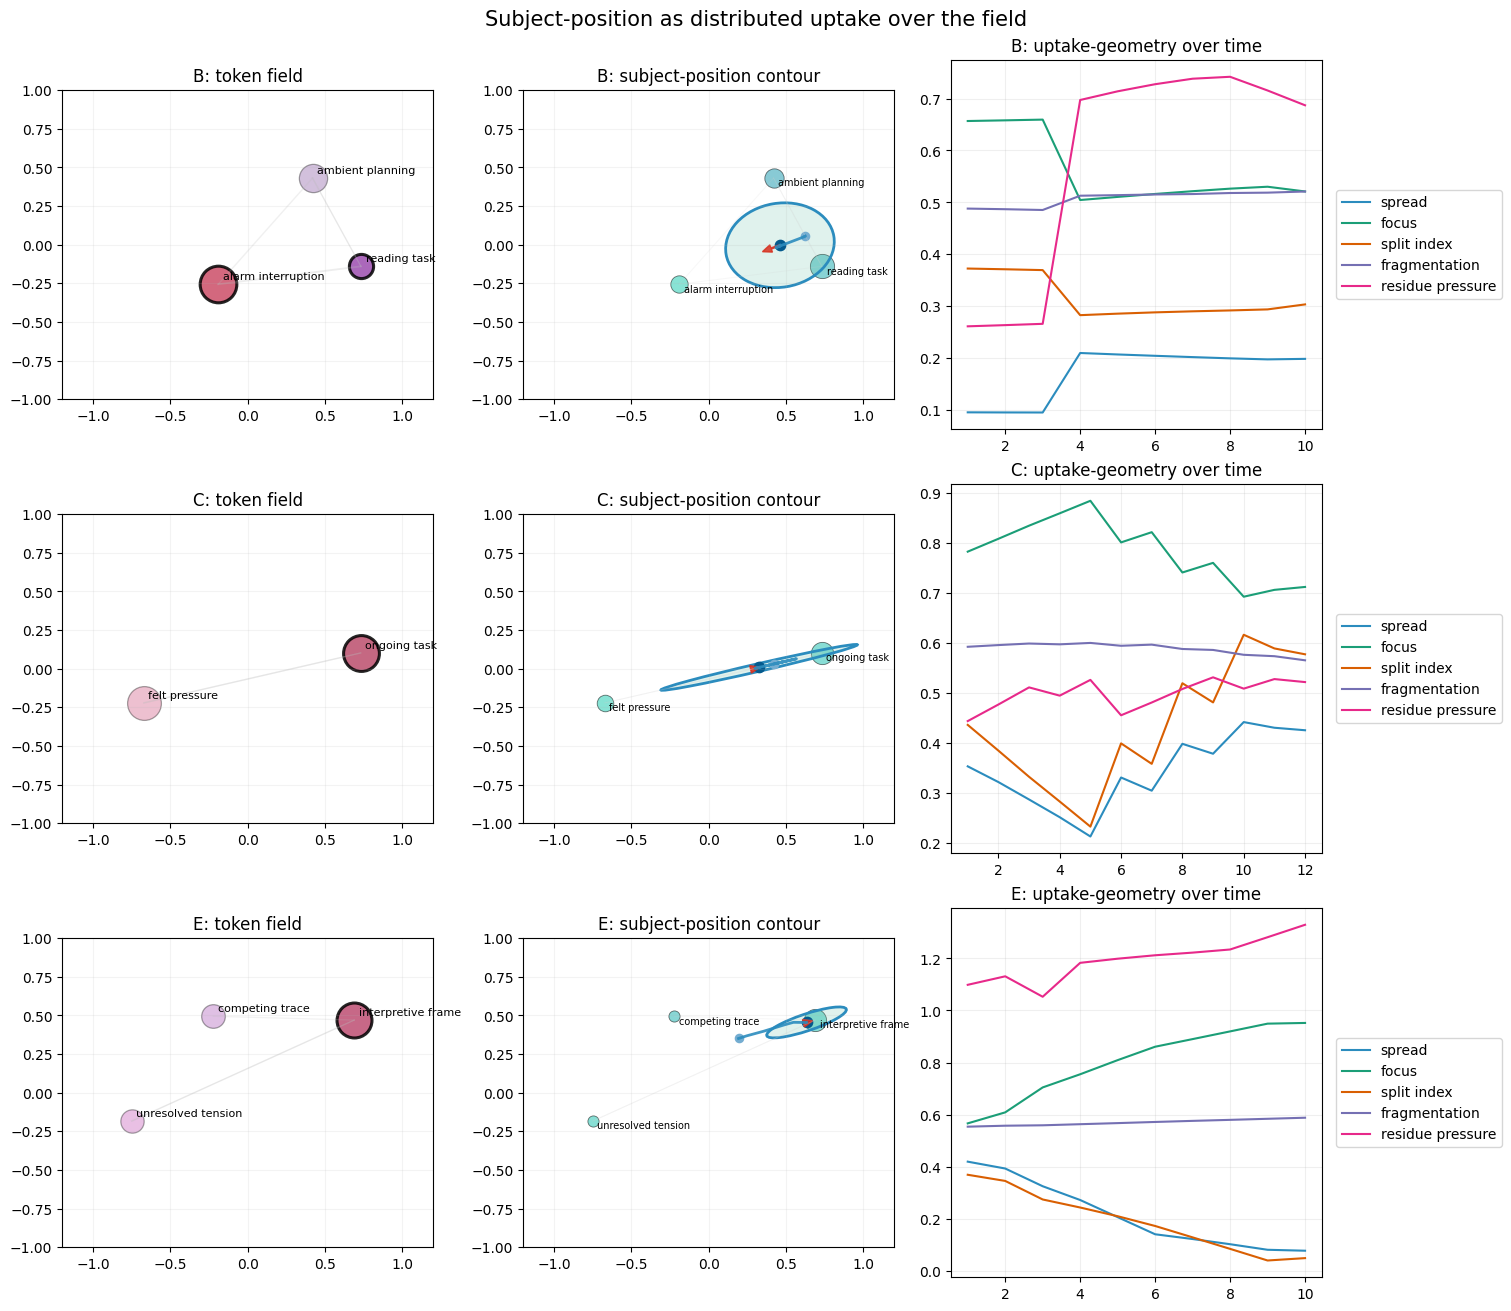

Subject-position artifacts saved to portable_artifacts/subject_position/.


In [7]:
import math

MODE_ANCHORS = {
    "body": (-0.85, -0.55),
    "aff": (-0.55, 0.15),
    "mood": (-0.75, 0.5),
    "imag": (0.1, 0.75),
    "refl": (0.55, 0.75),
    "cog": (0.75, 0.15),
    "perc": (0.85, -0.45),
}

def _subject_table(headers: List[str], rows: List[List[str]]) -> str:
    header_line = "| " + " | ".join(headers) + " |"
    divider_line = "| " + " | ".join(["---"] * len(headers)) + " |"
    row_lines = ["| " + " | ".join(row) + " |" for row in rows]
    return "\n".join([header_line, divider_line, *row_lines])

def _label_offset(label: str) -> tuple[float, float]:
    seed = sum((index + 1) * ord(char) for index, char in enumerate(label))
    angle = math.radians(seed % 360)
    radius = 0.02 + ((seed // 17) % 7) * 0.008
    return radius * math.cos(angle), radius * math.sin(angle)

def _anchor_position(label: str, modes: Iterable[str]) -> tuple[float, float]:
    anchors = [MODE_ANCHORS[mode] for mode in sorted(set(modes)) if mode in MODE_ANCHORS]
    if not anchors:
        anchors = [(0.0, 0.0)]
    x = sum(point[0] for point in anchors) / len(anchors)
    y = sum(point[1] for point in anchors) / len(anchors)
    dx, dy = _label_offset(label)
    return x + dx, y + dy

def _token_positions(state: FieldState) -> Dict[str, tuple[float, float]]:
    return {token.label: _anchor_position(token.label, token.modes) for token in state.token_list()}

def _residue_positions(state: FieldState) -> Dict[str, tuple[float, float]]:
    positions = {}
    for trace in state.residue:
        positions[trace.label] = _anchor_position(trace.label, trace.modes)
    return positions

def _weighted_center(points: List[tuple[float, float]], weights: List[float]) -> tuple[float, float]:
    total = max(sum(weights), 1e-9)
    return (
        sum(weight * point[0] for point, weight in zip(points, weights)) / total,
        sum(weight * point[1] for point, weight in zip(points, weights)) / total,
    )

def _weighted_covariance(points: List[tuple[float, float]], weights: List[float], center: tuple[float, float]) -> Dict[str, float]:
    total = max(sum(weights), 1e-9)
    xx = sum(weight * (point[0] - center[0]) ** 2 for point, weight in zip(points, weights)) / total
    xy = sum(weight * (point[0] - center[0]) * (point[1] - center[1]) for point, weight in zip(points, weights)) / total
    yy = sum(weight * (point[1] - center[1]) ** 2 for point, weight in zip(points, weights)) / total
    return {"xx": xx, "xy": xy, "yy": yy}

def _covariance_axes(covariance: Dict[str, float]) -> tuple[float, float, float]:
    xx = covariance["xx"]
    xy = covariance["xy"]
    yy = covariance["yy"]
    trace = xx + yy
    determinant = (xx * yy) - (xy * xy)
    discriminant = max((trace * trace) / 4.0 - determinant, 0.0)
    lambda_major = trace / 2.0 + math.sqrt(discriminant)
    lambda_minor = trace / 2.0 - math.sqrt(discriminant)
    angle = 0.5 * math.atan2(2.0 * xy, xx - yy)
    return max(lambda_major, 0.0), max(lambda_minor, 0.0), angle

def _subject_orientation_vector(state: FieldState, positions: Dict[str, tuple[float, float]], center: tuple[float, float]) -> tuple[float, float]:
    vectors = []
    weights = []
    for token in state.token_list():
        position = positions[token.label]
        dx = position[0] - center[0]
        dy = position[1] - center[1]
        pull = max(0.01, token.uptake) * max(0.05, (token.salience + token.weighting) / 2.0)
        vectors.append((dx, dy))
        weights.append(pull)
    total = max(sum(weights), 1e-9)
    vector = (
        sum(weight * vector[0] for vector, weight in zip(vectors, weights)) / total,
        sum(weight * vector[1] for vector, weight in zip(vectors, weights)) / total,
    )
    magnitude = math.sqrt(vector[0] ** 2 + vector[1] ** 2)
    if magnitude < 1e-9:
        return (0.0, 0.0)
    scale = min(0.35, magnitude) / magnitude
    return vector[0] * scale, vector[1] * scale

def _split_index(state: FieldState, positions: Dict[str, tuple[float, float]], weights: Dict[str, float]) -> float:
    ranked = sorted(weights.items(), key=lambda item: item[1], reverse=True)
    if len(ranked) < 2:
        return 0.0
    total = max(sum(weights.values()), 1e-9)
    (label_a, weight_a), (label_b, weight_b) = ranked[:2]
    point_a = positions[label_a]
    point_b = positions[label_b]
    distance = math.dist(point_a, point_b)
    shared_mass = (weight_a + weight_b) / total
    balance = 1.0 - min(1.0, abs(weight_a - weight_b) / max(weight_a + weight_b, 1e-9))
    return round(clamp(shared_mass * balance * min(1.0, distance / 1.2), 0.0, 1.0), 4)

def _subject_position_geometry(state: FieldState) -> Dict[str, object]:
    positions = _token_positions(state)
    tokens = state.token_list()
    if not tokens:
        return {
            "center": (0.0, 0.0),
            "covariance": {"xx": 0.0, "xy": 0.0, "yy": 0.0},
            "major_axis": 0.0,
            "minor_axis": 0.0,
            "angle": 0.0,
            "orientation": (0.0, 0.0),
            "focus": 0.0,
            "spread": 0.0,
            "split_index": 0.0,
            "positions": positions,
            "weights": {},
        }
    weights = {token.label: max(token.uptake, 0.02) for token in tokens}
    points = [positions[token.label] for token in tokens]
    weight_values = [weights[token.label] for token in tokens]
    center = _weighted_center(points, weight_values)
    covariance = _weighted_covariance(points, weight_values, center)
    major_axis, minor_axis, angle = _covariance_axes(covariance)
    orientation = _subject_orientation_vector(state, positions, center)
    focus = max(weight_values) / max(sum(weight_values), 1e-9)
    spread = covariance["xx"] + covariance["yy"]
    return {
        "center": center,
        "covariance": covariance,
        "major_axis": major_axis,
        "minor_axis": minor_axis,
        "angle": angle,
        "orientation": orientation,
        "focus": focus,
        "spread": spread,
        "split_index": _split_index(state, positions, weights),
        "positions": positions,
        "weights": weights,
    }

def _simulate_snapshots(scenario: Scenario) -> List[FieldState]:
    simulator = FieldSimulator(scenario.build_state())
    snapshots = []
    for step in range(1, scenario.steps + 1):
        simulator.step(scenario.interventions.get(step, {}))
        snapshots.append(deepcopy(simulator.state))
    return snapshots

def subject_position_series(scenario_code: str) -> List[Dict[str, object]]:
    scenario = get_scenario(scenario_code)
    snapshots = _simulate_snapshots(scenario)
    rows = []
    last_center = None
    movement_steps = []
    for state in snapshots:
        geometry = _subject_position_geometry(state)
        center = geometry["center"]
        movement = 0.0 if last_center is None else math.dist(center, last_center)
        movement_steps.append(movement)
        last_center = center
        metrics = metric_snapshot(state)
        rows.append({
            "step": state.step_index,
            "center_x": round(center[0], 4),
            "center_y": round(center[1], 4),
            "spread": round(geometry["spread"], 4),
            "focus": round(geometry["focus"], 4),
            "split_index": round(geometry["split_index"], 4),
            "orientation_x": round(geometry["orientation"][0], 4),
            "orientation_y": round(geometry["orientation"][1], 4),
            "coherence": metrics["coherence"],
            "integration": metrics["integration"],
            "fragmentation": metrics["fragmentation"],
            "residue_pressure": metrics["residue_pressure"],
            "major_axis": round(geometry["major_axis"], 4),
            "minor_axis": round(geometry["minor_axis"], 4),
        })
    avg_movement = sum(movement_steps[1:]) / max(1, len(movement_steps[1:]))
    stability = round(clamp(1.0 - min(1.0, avg_movement / 0.28), 0.0, 1.0), 4)
    for row in rows:
        row["trail_stability"] = stability
    return rows

def _draw_subject_position_panel(scenario_code: str, axis_row, save_root: Path) -> Dict[str, object]:
    scenario = get_scenario(scenario_code)
    snapshots = _simulate_snapshots(scenario)
    final_state = snapshots[-1]
    geometry_by_step = [_subject_position_geometry(state) for state in snapshots]
    final_geometry = geometry_by_step[-1]
    trail = [geometry["center"] for geometry in geometry_by_step]
    final_metrics = metric_snapshot(final_state)
    residue_positions = _residue_positions(final_state)

    field_axis, subject_axis, metric_axis = axis_row

    final_positions = final_geometry["positions"]
    for (source, target), weight in final_state.relations.items():
        if source in final_positions and target in final_positions:
            xs = [final_positions[source][0], final_positions[target][0]]
            ys = [final_positions[source][1], final_positions[target][1]]
            field_axis.plot(xs, ys, color="#bbbbbb", linewidth=0.8 + 1.2 * abs(weight), alpha=0.18 + 0.2 * abs(weight))
            subject_axis.plot(xs, ys, color="#d0d0d0", linewidth=0.7, alpha=0.16)

    for token in final_state.token_list():
        x, y = final_positions[token.label]
        size = 150 + 550 * token.salience
        alpha = 0.35 if token.fg_bg_position < 0.0 else 0.85
        edge_width = 2.2 if token.fg_bg_position >= FG_THRESHOLD else 0.9
        field_axis.scatter(x, y, s=size, c=[[0.2 + 0.6 * token.weighting, 0.3, 0.8 - 0.4 * token.salience]], alpha=alpha, edgecolors="black", linewidths=edge_width)
        field_axis.text(x + 0.03, y + 0.03, token.label, fontsize=8)

        subject_axis.scatter(x, y, s=65 + 240 * token.uptake, c=[[0.15, 0.45 + 0.35 * token.weighting, 0.7]], alpha=0.55, edgecolors="black", linewidths=0.6)
        subject_axis.text(x + 0.03, y - 0.05, token.label, fontsize=7)

    for label, (x, y) in residue_positions.items():
        field_axis.scatter(x, y, s=130, facecolors="none", edgecolors="#cc6600", linewidths=1.4, alpha=0.75)
        field_axis.text(x + 0.03, y + 0.03, f"residue:{label}", fontsize=7, color="#aa5500")
        subject_axis.scatter(x, y, s=95, facecolors="none", edgecolors="#cc6600", linewidths=1.1, alpha=0.65)

    if plt is not None:
        try:
            from matplotlib.patches import Ellipse
            width = 2.0 * math.sqrt(max(final_geometry["major_axis"], 1e-9))
            height = 2.0 * math.sqrt(max(final_geometry["minor_axis"], 1e-9))
            angle = math.degrees(final_geometry["angle"])
            subject_axis.add_patch(Ellipse(final_geometry["center"], width=max(width, 0.08), height=max(height, 0.05), angle=angle, facecolor="#66c2a533", edgecolor="#2b8cbe", linewidth=2.0))
        except Exception:
            pass

    subject_axis.plot([point[0] for point in trail], [point[1] for point in trail], color="#2b8cbe", linewidth=2.0, alpha=0.9)
    subject_axis.scatter(trail[0][0], trail[0][1], s=35, color="#74add1", label="start")
    subject_axis.scatter(trail[-1][0], trail[-1][1], s=55, color="#045a8d", label="end")
    center_x, center_y = final_geometry["center"]
    orient_x, orient_y = final_geometry["orientation"]
    subject_axis.arrow(center_x, center_y, orient_x, orient_y, width=0.008, head_width=0.05, head_length=0.06, color="#d7301f", alpha=0.85, length_includes_head=True)

    for axis in [field_axis, subject_axis]:
        axis.set_xlim(-1.2, 1.2)
        axis.set_ylim(-1.0, 1.0)
        axis.set_aspect("equal")
        axis.grid(alpha=0.15)

    field_axis.set_title(f"{scenario.code}: token field")
    subject_axis.set_title(f"{scenario.code}: subject-position contour")

    series = subject_position_series(scenario_code)
    steps = [row["step"] for row in series]
    metric_axis.plot(steps, [row["spread"] for row in series], label="spread", color="#2b8cbe")
    metric_axis.plot(steps, [row["focus"] for row in series], label="focus", color="#1b9e77")
    metric_axis.plot(steps, [row["split_index"] for row in series], label="split index", color="#d95f02")
    metric_axis.plot(steps, [row["fragmentation"] for row in series], label="fragmentation", color="#7570b3")
    metric_axis.plot(steps, [row["residue_pressure"] for row in series], label="residue pressure", color="#e7298a")
    metric_axis.set_title(f"{scenario.code}: uptake-geometry over time")
    metric_axis.grid(alpha=0.2)
    metric_axis.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

    save_root.mkdir(parents=True, exist_ok=True)
    return {
        "code": scenario.code,
        "regime_name": scenario.regime_name,
        "scenario_role": scenario.scenario_role,
        "focus": round(final_geometry["focus"], 4),
        "spread": round(final_geometry["spread"], 4),
        "split_index": round(final_geometry["split_index"], 4),
        "center": [round(center_x, 4), round(center_y, 4)],
        "orientation": [round(orient_x, 4), round(orient_y, 4)],
        "fragmentation": final_metrics["fragmentation"],
        "residue_pressure": final_metrics["residue_pressure"],
        "trail_stability": series[-1]["trail_stability"],
    }

subject_result_by_code = {result.code: result for result in results}
subject_rows = []
subject_summary = {}

for code in ["A", "B", "C", "D", "E", "F"]:
    series = subject_position_series(code)
    final_row = series[-1]
    result = subject_result_by_code[code]
    subject_summary[code] = {
        "scenario_role": result.scenario_role,
        "regime_name": result.regime_name,
        "center": [final_row["center_x"], final_row["center_y"]],
        "spread": final_row["spread"],
        "focus": final_row["focus"],
        "split_index": final_row["split_index"],
        "trail_stability": final_row["trail_stability"],
        "primary_failures": result.primary_failures,
        "secondary_failures": result.secondary_failures,
    }
    subject_rows.append([
        code,
        result.regime_name,
        result.scenario_role,
        f"({final_row['center_x']:+.2f}, {final_row['center_y']:+.2f})",
        f"{final_row['spread']:.3f}",
        f"{final_row['focus']:.3f}",
        f"{final_row['split_index']:.3f}",
        f"{final_row['trail_stability']:.3f}",
        ", ".join(result.primary_failures) if result.primary_failures else "none",
    ])

subject_table_md = _subject_table(
    ["Scenario", "Regime", "Role", "Center", "Spread", "Focus", "Split index", "Trail stability", "Primary failures"],
    subject_rows,
 )

subject_root = Path("portable_artifacts") / "subject_position"
subject_root.mkdir(parents=True, exist_ok=True)
(subject_root / "subject_position_summary.json").write_text(json.dumps(subject_summary, indent=2), encoding="utf-8")

try:
    from IPython.display import Markdown, display
    display(Markdown("## Subject-position summary\n\n" + subject_table_md))
except Exception:
    print("## Subject-position summary\n")
    print(subject_table_md)

if plt is not None:
    figure, axes = plt.subplots(3, 3, figsize=(15, 13), constrained_layout=True)
    for scenario_code, axis_row in zip(["B", "C", "E"], axes):
        _draw_subject_position_panel(scenario_code, axis_row, subject_root)
    figure.suptitle("Subject-position as distributed uptake over the field", fontsize=15)
    figure.savefig(subject_root / "subject_position_panels.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figure)
else:
    print("matplotlib unavailable; subject-position panel figure skipped. Summary JSON still written.")

print(f"Subject-position artifacts saved to {subject_root.as_posix()}/.")

## Parameter sweeps across all scenarios

This section perturbs every canonical scenario with at least two variants. Its purpose is comparative perturbation rather than exhaustive regime mapping: it shows how qualitative behavior shifts when pressure, interruption strength, articulation rate, recurrence strength, closure force, or fragmentation pressure are changed in a controlled way.

A more systematic ratio sweep follows below. That later section moves one governing ratio at a time while holding the paired parameter budget roughly fixed, which is a better probe of regime boundaries than ordinary scenario variants alone.

In [16]:
default_sweeps = {
    "A": [
        SweepVariant("low_fatigue", {3: {"orientation_delta": {"fatigue_pressure": 0.03}}}),
        SweepVariant("high_fatigue", {3: {"orientation_delta": {"fatigue_pressure": 0.16}}, 7: {"impulses": {"task demand": {"uptake": -0.16}}}}),
    ],
    "B": [
        SweepVariant(
            "muted_alarm",
            {
                4: {
                    "emergent": [
                        {
                            "label": "alarm interruption",
                            "modes": {"perc", "aff", "body"},
                            "salience": 0.66,
                            "articulation": 0.38,
                            "carriage": 0.34,
                            "uptake": 0.31,
                            "weighting": 0.58,
                            "fg_bg_position": 0.56,
                        }
                    ]
                }
            },
        ),
        SweepVariant(
            "shock_alarm",
            {
                4: {
                    "emergent": [
                        {
                            "label": "alarm interruption",
                            "modes": {"perc", "aff", "body"},
                            "salience": 0.9,
                            "articulation": 0.5,
                            "carriage": 0.44,
                            "uptake": 0.4,
                            "weighting": 0.85,
                            "fg_bg_position": 0.82,
                        }
                    ],
                    "relation_updates": {
                        ("alarm interruption", "reading task"): -0.55,
                        ("alarm interruption", "ambient planning"): -0.26,
                    },
                },
                5: {"orientation_delta": {"threat_readiness": 0.3}},
            },
        ),
    ],
    "C": [
        SweepVariant(
            "slow_articulation",
            {
                4: {"impulses": {"felt pressure": {"carriage": 0.06, "articulation": 0.05}}},
                6: {"impulses": {"felt pressure": {"articulation": 0.09, "uptake": 0.06, "fg_bg_position": 0.1}}},
            },
        ),
        SweepVariant(
            "rapid_articulation",
            {
                4: {"impulses": {"felt pressure": {"carriage": 0.14, "articulation": 0.12}}},
                6: {"impulses": {"felt pressure": {"articulation": 0.18, "uptake": 0.14, "fg_bg_position": 0.18}}},
                8: {"impulses": {"felt pressure": {"uptake": 0.16, "carriage": 0.12}}},
            },
        ),
    ],
    "D": [
        SweepVariant("weak_reentry", {7: {"impulses": {"returning memory": {"salience": 0.08, "weighting": 0.05}}}}),
        SweepVariant("strong_reentry", {7: {"impulses": {"returning memory": {"salience": 0.24, "weighting": 0.20, "fg_bg_position": 0.18}}}}),
    ],
    "E": [
        SweepVariant(
            "tentative_closure",
            {
                3: {"impulses": {"interpretive frame": {"articulation": 0.14, "uptake": 0.06, "weighting": 0.04}}},
                4: {"impulses": {"unresolved tension": {"weighting": 0.1}, "competing trace": {"weighting": 0.08}}},
            },
        ),
        SweepVariant(
            "hard_closure",
            {
                3: {"impulses": {"interpretive frame": {"articulation": 0.28, "uptake": 0.14, "weighting": 0.12}}},
                4: {"impulses": {"unresolved tension": {"weighting": 0.12}, "competing trace": {"weighting": 0.1}}},
                6: {"orientation_delta": {"withdrawal_tendency": 0.14}},
            },
        ),
    ],
    "F": [
        SweepVariant("moderate_split", {5: {"relation_updates": {("bodily alarm", "narrative monitor"): -0.28}}}),
        SweepVariant("severe_split", {5: {"relation_updates": {("bodily alarm", "narrative monitor"): -0.52, ("social scan", "narrative monitor"): -0.32}}, 8: {"subject_delta": {"agency": -0.18, "stability": -0.08}}}),
    ],
}

sweep_results = {code: run_parameter_sweep(code, variants) for code, variants in default_sweeps.items()}
baseline_by_code = {result.code: result for result in results}

sweep_summary = {}
for code, variant_results in sweep_results.items():
    baseline_metrics = baseline_by_code[code].metric_rows[-1]
    sweep_summary[code] = []
    for variant_result in variant_results:
        final_metrics = variant_result.metric_rows[-1]
        active_failures = [
            name
            for name, value in variant_result.final_failures.items()
            if (isinstance(value, list) and value) or (isinstance(value, bool) and value)
        ]
        sweep_summary[code].append(
            {
                "code": variant_result.code,
                "name": variant_result.name,
                "regime_name": variant_result.regime_name,
                "scenario_role": variant_result.scenario_role,
                "derived_ratios": variant_result.derived_ratios,
                "primary_failures": variant_result.primary_failures,
                "secondary_failures": variant_result.secondary_failures,
                "interpretation_notes": variant_result.interpretation_notes,
                "final_metrics": final_metrics,
                "delta_from_baseline": {
                    "coherence": round(final_metrics["coherence"] - baseline_metrics["coherence"], 4),
                    "integration": round(final_metrics["integration"] - baseline_metrics["integration"], 4),
                    "fragmentation": round(final_metrics["fragmentation"] - baseline_metrics["fragmentation"], 4),
                    "residue_pressure": round(final_metrics["residue_pressure"] - baseline_metrics["residue_pressure"], 4),
                },
                "active_failures": active_failures,
            }
        )

sweep_summary_path = Path("portable_artifacts") / "sweeps" / "sweep_summary.json"
sweep_summary_path.parent.mkdir(parents=True, exist_ok=True)
sweep_summary_path.write_text(json.dumps(sweep_summary, indent=2), encoding="utf-8")
print(json.dumps(sweep_summary, indent=2))
print(f"Sweep artifacts saved to portable_artifacts/sweeps/. Summary written to {sweep_summary_path.as_posix()}.")

{
  "A": [
    {
      "code": "A_low_fatigue",
      "name": "Task plus background worry plus fatigue [low_fatigue]",
      "regime_name": "open_revisable",
      "scenario_role": "baseline",
      "derived_ratios": {
        "closure_to_correction": 0.4487,
        "salience_to_articulation": 1.5,
        "persistence_to_decay": 1.2222,
        "cross_mode_integration": 0.72
      },
      "primary_failures": [
        "failed_uptake",
        "weak_carriage"
      ],
      "secondary_failures": [
        "fixation"
      ],
      "interpretation_notes": "Baseline case: open/revisable dynamics remain mostly adaptive, but background pressure leaves partial uptake unresolved.",
      "final_metrics": {
        "step": 12,
        "coherence": 0.4203,
        "integration": 0.4214,
        "fragmentation": 0.5792,
        "residue_pressure": 0.9981,
        "field_diversity": 0.7143
      },
      "delta_from_baseline": {
        "coherence": -0.001,
        "integration": 0.0029,
     

## Focused ratio sweeps

This section adds two true ratio sweeps. Instead of changing arbitrary scenario-local details, it moves one governing ratio while keeping the paired parameter budget roughly fixed so boundary behavior is easier to inspect.

The closure/correction sweep probes interpretive hardening in Scenario E. The salience/articulation sweep probes whether pressure can be metabolized into articulation in Scenario C. As above, any failure labels should still be read as operational signatures within this toy model rather than as literal categories of consciousness or psychopathology.

In [17]:
def _parameterized_scenario(base_scenario: Scenario, suffix: str, parameter_updates: Mapping[str, float]) -> Scenario:
    def build_state() -> FieldState:
        state = base_scenario.build_state()
        payload = state.parameters.as_dict()
        payload.update(parameter_updates)
        state.parameters = ParameterSet(**payload).normalized()
        return state

    return Scenario(
        code=f"{base_scenario.code}_{suffix}",
        name=f"{base_scenario.name} [{suffix}]",
        description=base_scenario.description,
        steps=base_scenario.steps,
        regime_name=base_scenario.regime_name,
        scenario_role=base_scenario.scenario_role,
        build_state=build_state,
        interventions=deepcopy(base_scenario.interventions),
        expected_behaviors=base_scenario.expected_behaviors,
    )

def _closure_correction_updates(base: ParameterSet, target_ratio: float) -> Dict[str, float]:
    total = base.closure_weight + base.correction_sensitivity
    correction = clamp(total / (1.0 + target_ratio), 0.05, 0.98)
    closure = clamp(total - correction, 0.05, 0.98)
    return {
        "closure_weight": closure,
        "correction_sensitivity": correction,
    }

def _salience_articulation_updates(base: ParameterSet, target_ratio: float) -> Dict[str, float]:
    total = base.salience_gain + base.articulation_bandwidth
    fixed_affect = base.affective_amplification
    articulation = clamp((total + fixed_affect) / (1.0 + target_ratio), 0.08, 0.95)
    salience = clamp(total - articulation, 0.05, 0.98)
    return {
        "salience_gain": salience,
        "articulation_bandwidth": articulation,
    }

ratio_sweep_specs = [
    {
        "axis": "closure_to_correction",
        "label": "Closure/correction boundary",
        "scenario_code": "E",
        "targets": [1.0, 1.6, 2.2, 3.0, 3.8, 4.6],
        "builder": _closure_correction_updates,
    },
    {
        "axis": "salience_to_articulation",
        "label": "Salience/articulation boundary",
        "scenario_code": "C",
        "targets": [2.5, 3.5, 4.5, 5.6, 6.7, 7.8],
        "builder": _salience_articulation_updates,
    },
]

ratio_sweep_summary = {}
ratio_rows = []

for spec in ratio_sweep_specs:
    base_scenario = get_scenario(spec["scenario_code"])
    base_parameters = base_scenario.build_state().parameters
    baseline_result = baseline_by_code[spec["scenario_code"]]
    baseline_metrics = baseline_result.metric_rows[-1]
    ratio_sweep_summary[spec["axis"]] = []

    for target_ratio in spec["targets"]:
        parameter_updates = spec["builder"](base_parameters, target_ratio)
        suffix = f"{spec['axis']}_{str(target_ratio).replace('.', '_')}"
        scenario = _parameterized_scenario(base_scenario, suffix, parameter_updates)
        result = run_scenario(scenario, output_root=Path("portable_artifacts") / "ratio_sweeps" / spec["axis"])
        final_metrics = result.metric_rows[-1]
        achieved_ratio = result.derived_ratios[spec["axis"]]
        summary = {
            "axis": spec["axis"],
            "label": spec["label"],
            "scenario_code": spec["scenario_code"],
            "scenario_role": result.scenario_role,
            "target_ratio": round(target_ratio, 4),
            "achieved_ratio": round(achieved_ratio, 4),
            "parameters": result.parameters,
            "primary_failures": result.primary_failures,
            "secondary_failures": result.secondary_failures,
            "interpretation_notes": result.interpretation_notes,
            "delta_from_baseline": {
                "coherence": round(final_metrics["coherence"] - baseline_metrics["coherence"], 4),
                "integration": round(final_metrics["integration"] - baseline_metrics["integration"], 4),
                "fragmentation": round(final_metrics["fragmentation"] - baseline_metrics["fragmentation"], 4),
                "residue_pressure": round(final_metrics["residue_pressure"] - baseline_metrics["residue_pressure"], 4),
            },
        }
        ratio_sweep_summary[spec["axis"]].append(summary)
        delta = summary["delta_from_baseline"]
        ratio_rows.append([
            spec["label"],
            spec["scenario_code"],
            result.scenario_role,
            f"target={target_ratio:.2f}",
            f"achieved={achieved_ratio:.2f}",
            f"ΔC={delta['coherence']:+.03f}; ΔI={delta['integration']:+.03f}",
            f"ΔF={delta['fragmentation']:+.03f}; ΔR={delta['residue_pressure']:+.03f}",
            ", ".join(result.primary_failures) if result.primary_failures else "none",
            ", ".join(result.secondary_failures) if result.secondary_failures else "none",
            result.interpretation_notes,
        ])

ratio_sweep_path = Path("portable_artifacts") / "ratio_sweeps" / "ratio_sweep_summary.json"
ratio_sweep_path.parent.mkdir(parents=True, exist_ok=True)
ratio_sweep_path.write_text(json.dumps(ratio_sweep_summary, indent=2), encoding="utf-8")

ratio_table_md = _markdown_table(
    [
        "Sweep",
        "Scenario",
        "Role",
        "Target ratio",
        "Achieved ratio",
        "Baseline deltas",
        "Stress deltas",
        "Primary failures",
        "Secondary failures",
        "Interpretation",
    ],
    ratio_rows,
 )

try:
    from IPython.display import Markdown, display
    display(Markdown("## Ratio sweep table\n\n" + ratio_table_md))
except Exception:
    print("## Ratio sweep table\n")
    print(ratio_table_md)

print(f"Ratio sweep artifacts saved to {ratio_sweep_path.as_posix()}.")

## Ratio sweep table

| Sweep | Scenario | Role | Target ratio | Achieved ratio | Baseline deltas | Stress deltas | Primary failures | Secondary failures | Interpretation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Closure/correction boundary | E | breakdown | target=1.00 | achieved=1.00 | ΔC=+0.015; ΔI=+0.010 | ΔF=-0.012; ΔR=+0.010 | fixation, failed_uptake | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| Closure/correction boundary | E | breakdown | target=1.60 | achieved=1.60 | ΔC=+0.009; ΔI=+0.006 | ΔF=-0.007; ΔR=+0.006 | premature_closure, fixation, failed_uptake | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| Closure/correction boundary | E | breakdown | target=2.20 | achieved=2.20 | ΔC=+0.005; ΔI=+0.003 | ΔF=-0.004; ΔR=+0.004 | premature_closure, fixation, failed_uptake | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| Closure/correction boundary | E | breakdown | target=3.00 | achieved=3.00 | ΔC=+0.002; ΔI=+0.001 | ΔF=-0.002; ΔR=+0.002 | premature_closure, fixation, failed_uptake | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| Closure/correction boundary | E | breakdown | target=3.80 | achieved=3.80 | ΔC=+0.000; ΔI=+0.000 | ΔF=-0.000; ΔR=+0.000 | premature_closure, fixation, failed_uptake | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| Closure/correction boundary | E | breakdown | target=4.60 | achieved=4.60 | ΔC=-0.001; ΔI=-0.001 | ΔF=+0.001; ΔR=-0.001 | premature_closure, fixation | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| Salience/articulation boundary | C | transition | target=2.50 | achieved=2.50 | ΔC=-0.012; ΔI=+0.009 | ΔF=+0.002; ΔR=-0.052 | none | none | Transition case: pressure-heavy starting conditions are successfully metabolized into articulation and uptake. |
| Salience/articulation boundary | C | transition | target=3.50 | achieved=3.50 | ΔC=-0.006; ΔI=+0.005 | ΔF=+0.001; ΔR=-0.022 | none | none | Transition case: pressure-heavy starting conditions are successfully metabolized into articulation and uptake. |
| Salience/articulation boundary | C | transition | target=4.50 | achieved=4.50 | ΔC=-0.001; ΔI=+0.002 | ΔF=-0.001; ΔR=-0.010 | none | none | Transition case: pressure-heavy starting conditions are successfully metabolized into articulation and uptake. |
| Salience/articulation boundary | C | transition | target=5.60 | achieved=5.60 | ΔC=-0.000; ΔI=+0.000 | ΔF=+0.000; ΔR=-0.000 | none | none | Transition case: pressure-heavy starting conditions are successfully metabolized into articulation and uptake. |
| Salience/articulation boundary | C | transition | target=6.70 | achieved=6.70 | ΔC=+0.003; ΔI=-0.001 | ΔF=-0.001; ΔR=+0.006 | none | none | Transition case: pressure-heavy starting conditions are successfully metabolized into articulation and uptake. |
| Salience/articulation boundary | C | transition | target=7.80 | achieved=7.80 | ΔC=+0.003; ΔI=-0.004 | ΔF=+0.001; ΔR=+0.011 | failed_uptake | none | Transition case: pressure remains behaviorally important, but the end-state no longer looks broadly destabilized. |

Ratio sweep artifacts saved to portable_artifacts/ratio_sweeps/ratio_sweep_summary.json.


## Comparative sweep summary

This final table compares each sweep variant against its baseline scenario. Reporting deltas makes the notebook easier to read as a standalone reference: the reader can see not only the final state of a variant, but also what changed relative to the corresponding baseline regime.

As in the baseline table and the ratio-sweep table, the named failures are operational signatures produced by this detector scheme. They are useful for comparing model behavior, but they should not be read as general measurements or diagnoses of consciousness.

In [18]:
sweep_rows = []
for code, variant_summaries in sweep_summary.items():
    for summary in variant_summaries:
        delta = summary["delta_from_baseline"]
        ratios = summary["derived_ratios"]
        sweep_rows.append([
            code,
            summary["code"].split("_", 1)[1],
            summary["regime_name"],
            summary["scenario_role"],
            f"ΔC={delta['coherence']:+.03f}; ΔI={delta['integration']:+.03f}",
            f"ΔF={delta['fragmentation']:+.03f}; ΔR={delta['residue_pressure']:+.03f}",
            f"C/C={ratios['closure_to_correction']:.2f}; P/D={ratios['persistence_to_decay']:.2f}",
            ", ".join(summary["primary_failures"]) if summary["primary_failures"] else "none",
            ", ".join(summary["secondary_failures"]) if summary["secondary_failures"] else "none",
            summary["interpretation_notes"],
        ])

sweep_table_md = _markdown_table(
    ["Scenario", "Variant", "Regime", "Role", "Baseline deltas", "Stress deltas", "Key ratios", "Primary failures", "Secondary failures", "Interpretation"],
    sweep_rows,
)

try:
    from IPython.display import Markdown, display
    display(Markdown("## Sweep summary table\n\n" + sweep_table_md))
except Exception:
    print("## Sweep summary table\n")
    print(sweep_table_md)

## Sweep summary table

| Scenario | Variant | Regime | Role | Baseline deltas | Stress deltas | Key ratios | Primary failures | Secondary failures | Interpretation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A | low_fatigue | open_revisable | baseline | ΔC=-0.001; ΔI=+0.003 | ΔF=-0.001; ΔR=-0.009 | C/C=0.45; P/D=1.22 | failed_uptake, weak_carriage | fixation | Baseline case: open/revisable dynamics remain mostly adaptive, but background pressure leaves partial uptake unresolved. |
| A | high_fatigue | open_revisable | baseline | ΔC=-0.002; ΔI=-0.003 | ΔF=+0.002; ΔR=+0.014 | C/C=0.45; P/D=1.22 | failed_uptake, weak_carriage | none | Baseline case: open/revisable dynamics remain mostly adaptive, but background pressure leaves partial uptake unresolved. |
| B | muted_alarm | open_revisable | baseline | ΔC=+0.029; ΔI=-0.007 | ΔF=-0.011; ΔR=+0.048 | C/C=0.45; P/D=1.22 | fixation | none | Baseline case: open/revisable dynamics reorganize cleanly around interruption without broader breakdown. |
| B | shock_alarm | open_revisable | baseline | ΔC=-0.040; ΔI=+0.006 | ΔF=+0.017; ΔR=-0.134 | C/C=0.45; P/D=1.22 | fixation | none | Baseline case: open/revisable dynamics reorganize cleanly around interruption without broader breakdown. |
| C | slow_articulation | pressure_heavy | transition | ΔC=-0.003; ΔI=-0.008 | ΔF=+0.005; ΔR=+0.098 | C/C=1.37; P/D=1.22 | failed_uptake | none | Transition case: pressure remains behaviorally important, but the end-state no longer looks broadly destabilized. |
| C | rapid_articulation | pressure_heavy | transition | ΔC=+0.002; ΔI=+0.015 | ΔF=-0.009; ΔR=-0.107 | C/C=1.37; P/D=1.22 | none | none | Transition case: pressure-heavy starting conditions are successfully metabolized into articulation and uptake. |
| D | weak_reentry | fixation_rumination | breakdown | ΔC=-0.037; ΔI=-0.005 | ΔF=+0.021; ΔR=+0.009 | C/C=3.42; P/D=3.73 | fixation, failed_uptake | none | Breakdown case: high persistence and closure concentrate the field around a returning trace. |
| D | strong_reentry | fixation_rumination | breakdown | ΔC=-0.006; ΔI=+0.001 | ΔF=+0.003; ΔR=-0.416 | C/C=3.42; P/D=3.73 | fixation, failed_uptake | none | Breakdown case: high persistence and closure concentrate the field around a returning trace. |
| E | tentative_closure | closure_heavy | breakdown | ΔC=+0.003; ΔI=-0.003 | ΔF=+0.000; ΔR=+0.035 | C/C=3.82; P/D=1.72 | premature_closure, fixation, failed_uptake | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| E | hard_closure | closure_heavy | breakdown | ΔC=-0.002; ΔI=+0.002 | ΔF=-0.000; ΔR=+0.064 | C/C=3.82; P/D=1.72 | premature_closure, fixation, failed_uptake | weak_carriage | Breakdown case: closure-heavy dynamics harden around an interpretive frame while unresolved competitors remain in play. |
| F | moderate_split | fragmentation_dissociation | breakdown | ΔC=+0.013; ΔI=-0.000 | ΔF=-0.006; ΔR=+0.006 | C/C=0.53; P/D=0.34 | fragmentation, dissociative_disconnection, fixation | weak_carriage, failed_uptake | Breakdown case: fragmentation and dissociative disconnection dominate, with secondary embodied dominance rather than primary closure. |
| F | severe_split | fragmentation_dissociation | breakdown | ΔC=-0.013; ΔI=+0.001 | ΔF=+0.006; ΔR=-0.010 | C/C=0.53; P/D=0.34 | fragmentation, dissociative_disconnection, fixation | weak_carriage, failed_uptake | Breakdown case: fragmentation and dissociative disconnection dominate, with secondary embodied dominance rather than primary closure. |